# 1. Setup

In [ ]:
!pip install langchain langchain-openai langchain-community langchain-classic openai wikipedia-api requests beautifulsoup4 PyPDF2 python-dotenv sentence-transformers transformers torch "gradio>=5.0,<6.0" -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.4/108.4 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 543.9/543.9 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 1.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests

In [ ]:
!apt-get update -qq
!apt-get install -y poppler-utils tesseract-ocr
!pip install pdf2image pytesseract pillow


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
The following NEW packages will be installed:
  poppler-utils
0 upgraded, 1 newly installed, 0 to remove and 13 not upgraded.
Need to get 186 kB of archives.
After this operation, 697 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 poppler-utils amd64 22.02.0-2ubuntu0.12 [186 kB]
Fetched 186 kB in 0s (1,759 kB/s)
Selecting previously unselected package poppler-utils.
(Reading database ... 118251 files and directories currently installed.)
Preparing to unpack .../poppler-utils_22.02.0-2ubuntu0.12_amd64.deb ...
Unpacking poppler-utils (22.02.0-2ubuntu0.12) ...
Setting up poppler-utils (22

In [ ]:
from langchain_openai import ChatOpenAI

In [ ]:
import os, shutil

os.environ["PATH"] = "/opt/homebrew/bin:/usr/local/bin:" + os.environ.get("PATH", "")

print("PATH:", os.environ["PATH"])
print("tesseract:", shutil.which("tesseract"))
print("pdftoppm:", shutil.which("pdftoppm"))


PATH: /opt/homebrew/bin:/usr/local/bin:/opt/bin:/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/sbin:/bin:/tools/node/bin:/tools/google-cloud-sdk/bin
tesseract: /usr/bin/tesseract
pdftoppm: /usr/bin/pdftoppm


In [ ]:
import os
from dotenv import load_dotenv

# Local/PyCharm: load keys from a .env file in the project folder.
# Colab: fall back to Colab Secrets if available.
load_dotenv()

try:
    from google.colab import userdata
    for key in ["OPENAI_API_KEY", "SERPER_API_KEY", "WANDB_API_KEY"]:
        value = userdata.get(key)
        if value:
            os.environ[key] = value
except Exception:
    pass

missing_keys = [key for key in ["OPENAI_API_KEY", "SERPER_API_KEY"] if not os.getenv(key)]
if missing_keys:
    print("Missing API keys:", missing_keys)
    print("Local/PyCharm: create a .env file from .env.example. Colab: add them in Secrets.")
else:
    print("API keys loaded successfully.")

API keys loaded successfully.


# 2. Web Search Tool

In [ ]:
# web search tool

import requests
from langchain.tools import tool

@tool
def web_search(query: str) -> str:
    """Search the web for current information. Use for up-to-date facts,
    recent events, statistics. Input should be a focused search query."""
    api_key = os.getenv("SERPER_API_KEY")
    if not api_key:
        return "Error: SERPER_API_KEY not set."

    url = "https://google.serper.dev/search"
    headers = {"X-API-KEY": api_key, "Content-Type": "application/json"}
    payload = {"q": query, "num": 5}

    try:
        response = requests.post(url, json=payload, headers=headers, timeout=10)
        response.raise_for_status()
        data = response.json()
    except requests.RequestException as e:
        return f"Error: {e}"

    results = []

    if "answerBox" in data:
        ab = data["answerBox"]
        answer = ab.get("answer") or ab.get("snippet") or ab.get("title", "")
        if answer:
            results.append(f"Quick Answer: {answer}")

    if "knowledgeGraph" in data:
        kg = data["knowledgeGraph"]
        if kg.get("title"):
            results.append(f"{kg['title']}: {kg.get('description', '')}")

    for i, item in enumerate(data.get("organic", [])[:5], 1):
        title = item.get("title", "No title")
        snippet = item.get("snippet", "No snippet")
        link = item.get("link", "")
        results.append(f"{i}. [{title}]({link})\n   {snippet}")

    return "\n\n".join(results) if results else "No results found."

/usr/local/lib/python3.12/dist-packages/langgraph/checkpoint/serde/encrypted.py:5: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


# 2. Wikipedia search tool


In [ ]:
# wikipedia tool

import wikipediaapi

@tool
def wikipedia_search(query: str) -> str:
    """Search Wikipedia for background info, definitions, and context.
    Best for established facts, history, scientific concepts, biographies."""
    wiki = wikipediaapi.Wikipedia(
        user_agent="ResearchAssistantAgent/1.0",
        language="en",
    )
    page = wiki.page(query)

    if not page.exists():
        page = wiki.page(query.strip().title())
        if not page.exists():
            return f"No Wikipedia article found for '{query}'. Try a different term."

    summary = page.summary
    if len(summary) > 2000:
        summary = summary[:2000] + "..."

    sections = [s.title for s in page.sections if s.title]
    section_list = ", ".join(sections[:10]) if sections else "None"

    return f"**{page.title}**\nURL: {page.fullurl}\n\n{summary}\n\nSections: {section_list}"

# 2. fetch pdf tool

In [ ]:
# pdf tool

import io
from PyPDF2 import PdfReader

@tool
def fetch_pdf(url: str) -> str:
    """Download and extract text from a PDF given its URL.
    Use for academic papers and reports."""
    if "arxiv.org/abs/" in url:
        url = url.replace("/abs/", "/pdf/")
        if not url.endswith(".pdf"):
            url += ".pdf"

    try:
        headers = {"User-Agent": "ResearchAssistantAgent/1.0"}
        response = requests.get(url, headers=headers, timeout=30)
        response.raise_for_status()

        reader = PdfReader(io.BytesIO(response.content))
        num_pages = len(reader.pages)
        max_pages = min(num_pages, 10)

        text_parts = []
        for i in range(max_pages):
            page_text = reader.pages[i].extract_text()
            if page_text:
                text_parts.append(f"--- Page {i+1} ---\n{page_text}")

        if not text_parts:
            return "Could not extract text. May be a scanned/image PDF."

        full_text = "\n\n".join(text_parts)
        if len(full_text) > 6000:
            full_text = full_text[:6000] + "\n\n[...truncated...]"

        return f"PDF: {url}\nPages: {num_pages} total ({max_pages} extracted)\n\n{full_text}"

    except Exception as e:
        return f"Error: {e}"

# 2. Generation citation tool

In [ ]:
@tool
def generate_citation(title: str, authors: str = "", year: str = "",
                      url: str = "", source_type: str = "web") -> str:
    """Generate a transparent citation for a source.
    Do not guess missing authors or years; leave them as n.d. / not identified."""
    authors = authors.strip() if authors else ""
    year = year.strip() if year else ""
    url = url.strip() if url else ""

    # Use conservative defaults instead of inventing bibliographic metadata.
    if not authors:
        if "wikipedia.org" in url:
            authors = "Wikipedia contributors"
        elif "arxiv.org" in url:
            authors = "Paper authors listed in source"
        else:
            authors = "Author not identified"

    if not year:
        # Only infer a year when it appears directly in the URL.
        import re
        year_match = re.search(r'(20\d{2})', url)
        if year_match:
            year = year_match.group(1)
        else:
            year = "n.d."

    if source_type == "paper":
        citation = f"{authors} ({year}). {title}."
    elif source_type == "wikipedia":
        citation = f'"{title}." Wikipedia. Wikimedia Foundation, {year}.'
    else:
        citation = f'{authors} ({year}). "{title}."'

    if url:
        citation += f" {url}"

    return f"Citation: {citation}\nNote: Missing author/year fields were not guessed."

# 3. Quote Retrieval Pipeline

In [ ]:
# --- Document loading and sentence processing ---
import os
import re
import requests
import io
from PyPDF2 import PdfReader

import nltk
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import sent_tokenize

DEFAULT_QUOTE_SOURCE_URL = "https://arxiv.org/pdf/1706.03762.pdf"
DEFAULT_QUOTE_SOURCE_NAME = "Attention Is All You Need"
quote_source_name = DEFAULT_QUOTE_SOURCE_NAME

def extract_text_from_pdf_bytes(pdf_bytes: bytes) -> str:
    reader = PdfReader(io.BytesIO(pdf_bytes))
    text = ""
    for page in reader.pages:
        extracted = page.extract_text()
        if extracted:
            text += extracted + "\n"
    return text

def load_default_quote_source() -> str:
    response = requests.get(DEFAULT_QUOTE_SOURCE_URL, timeout=30)
    response.raise_for_status()
    return extract_text_from_pdf_bytes(response.content)

def build_sentence_pool(source_text: str):
    raw_sentences = sent_tokenize(source_text)
    sentence_pool = []
    cursor = 0
    for s in raw_sentences:
        start = source_text.find(s, cursor)
        if start == -1:
            start = source_text.find(s)
        end = start + len(s) if start != -1 else -1
        cursor = end if end != -1 else cursor
        sentence_pool.append({
            "sentence": s,
            "start_char": start,
            "end_char": end,
        })
    return sentence_pool

# Filter extraction noise such as PDF headers, footers, URLs, and page labels.
def is_good_sentence(sent):
    clean = re.sub(r"\s+", " ", sent).strip()
    s = clean.lower()
    word_count = len(re.findall(r"\b\w+\b", clean))
    alpha_count = len(re.findall(r"[a-zA-Z]", clean))

    if len(clean) < 40 or word_count < 6 or alpha_count < 25:
        return False
    if re.search(r"https?://|www\.|\b[a-z0-9.-]+\.(com|org|net|edu|gov|life)\b", s):
        return False
    if any(marker in s for marker in ["table", "figure", "references", "bibliography"]):
        return False
    if "motivational quotes" in s and word_count < 12:
        return False
    if "@" in s:
        return False
    if re.match(r"^\s*(page\s*)?\d+\s*$", s) or re.match(r"^\d+\s*$", s):
        return False
    if clean.count("\n") > 2:
        return False
    return True

article_text = load_default_quote_source()
sentences = build_sentence_pool(article_text)
filtered_sentences = [s for s in sentences if is_good_sentence(s["sentence"])]
print(f"Quote source loaded: {quote_source_name} ({len(article_text)} characters)")
print(f"Filtered sentences: {len(filtered_sentences)}")


Quote source loaded: Attention Is All You Need (39487 characters)
Filtered sentences: 266


In [ ]:
# --- Paper loading and sentence processing ---
import re
import requests
import io
from PyPDF2 import PdfReader

# Load a default paper (Attention Is All You Need)
arxiv_url = "https://arxiv.org/pdf/1706.03762.pdf"
response = requests.get(arxiv_url)
pdf_file = io.BytesIO(response.content)
reader = PdfReader(pdf_file)

article_text = ""
for page in reader.pages:
    extracted = page.extract_text()
    if extracted:
        article_text += extracted + "\n"

print(f"Paper loaded: {len(article_text)} characters")

# Split into sentences
import nltk
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import sent_tokenize

raw_sentences = sent_tokenize(article_text)
sentences = []
for s in raw_sentences:
    start = article_text.find(s)
    sentences.append({
        "sentence": s,
        "start_char": start,
        "end_char": start + len(s)
    })

# Filter junk
def is_good_sentence(sent):
    s = sent.lower()
    if len(sent) < 40:
        return False
    if "table" in s or "figure" in s:
        return False
    if "@" in s:
        return False
    if "references" in s:
        return False
    if re.match(r'^\d+\s', s):
        return False
    return True

filtered_sentences = [s for s in sentences if is_good_sentence(s["sentence"])]
print(f"Filtered sentences: {len(filtered_sentences)}")

Paper loaded: 39487 characters
Filtered sentences: 262


In [ ]:
# --- Embedding model ---
from transformers import AutoTokenizer, AutoModel
import torch

embed_model_name = "intfloat/e5-small-v2"
embed_tokenizer = AutoTokenizer.from_pretrained(embed_model_name)
embed_model = AutoModel.from_pretrained(embed_model_name)
embed_model.eval()

def embed_text(texts, prefix="passage", batch_size=32):
    all_embeddings = []
    prefixed_texts = [f"{prefix}: {t}" for t in texts]

    for i in range(0, len(prefixed_texts), batch_size):
        batch = prefixed_texts[i:i + batch_size]
        inputs = embed_tokenizer(batch, padding=True, truncation=True, return_tensors="pt")
        with torch.no_grad():
            outputs = embed_model(**inputs)
        embeddings = outputs.last_hidden_state.mean(dim=1)
        embeddings = torch.nn.functional.normalize(embeddings, p=2, dim=1)
        all_embeddings.append(embeddings)

    return torch.cat(all_embeddings, dim=0)

def rebuild_quote_index(source_text: str, source_name: str = "Uploaded document") -> str:
    """Set the active quote source and rebuild sentence embeddings for quote_search."""
    global article_text, quote_source_name, sentences, filtered_sentences, sentence_embeddings

    article_text = source_text
    quote_source_name = source_name
    sentences = build_sentence_pool(article_text)
    filtered_sentences = [s for s in sentences if is_good_sentence(s["sentence"])]

    if not filtered_sentences:
        sentence_embeddings = None
        return f"Quote source '{quote_source_name}' loaded, but no usable sentences were found."

    sentence_texts = [s["sentence"] for s in filtered_sentences]
    sentence_embeddings = embed_text(sentence_texts, prefix="passage")
    return f"Quote source '{quote_source_name}' loaded with {len(filtered_sentences)} searchable sentences."

print(rebuild_quote_index(article_text, quote_source_name))
DEFAULT_QUOTE_STATE = {
    "article_text": article_text,
    "quote_source_name": quote_source_name,
    "sentences": sentences,
    "filtered_sentences": filtered_sentences,
    "sentence_embeddings": sentence_embeddings,
}

def reset_quote_source_to_default() -> str:
    """Reset active quote source after the UI file input is cleared."""
    global article_text, quote_source_name, sentences, filtered_sentences, sentence_embeddings
    article_text = DEFAULT_QUOTE_STATE["article_text"]
    quote_source_name = DEFAULT_QUOTE_STATE["quote_source_name"]
    sentences = DEFAULT_QUOTE_STATE["sentences"]
    filtered_sentences = DEFAULT_QUOTE_STATE["filtered_sentences"]
    sentence_embeddings = DEFAULT_QUOTE_STATE["sentence_embeddings"]
    return f"Quote source reset to default: {quote_source_name}"

print(f"Embeddings shape: {sentence_embeddings.shape}")

BertModel LOAD REPORT from: intfloat/e5-small-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Quote source 'Attention Is All You Need' loaded with 262 searchable sentences.
Embeddings shape: torch.Size([262, 384])


In [ ]:
# --- Reranker ---
from sentence_transformers import CrossEncoder

reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

def get_top_quotes_semantic(query, sentences, sentence_embeddings, top_k=5):
    query_emb = embed_text([query], prefix="query")
    scores = torch.matmul(sentence_embeddings, query_emb.T).flatten()
    scored = []
    for i, item in enumerate(sentences):
        scored.append({
            "sentence": item["sentence"],
            "score": float(scores[i]),
            "start_char": item["start_char"],
            "end_char": item["end_char"]
        })
    scored = sorted(scored, key=lambda x: x["score"], reverse=True)
    return scored[:top_k]

def rerank_quotes(query, candidates, top_k=3):
    if not candidates:
        return []
    pairs = [(query, c["sentence"]) for c in candidates]
    scores = reranker.predict(pairs)
    for c, s in zip(candidates, scores):
        c["rerank_score"] = float(s)
    ranked = sorted(candidates, key=lambda x: x["rerank_score"], reverse=True)
    return ranked[:top_k]

def verify_quote_in_source(quote_text, full_text):
    return quote_text in full_text

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
def parse_requested_quote_count(query: str, default: int = 3, max_quotes: int = 10) -> int:
    """Infer how many quotes the user requested. Defaults to 3 when unspecified."""
    q = query.lower()

    digit_match = re.search(r"\b(\d+)\b", q)
    if digit_match:
        return max(1, min(int(digit_match.group(1)), max_quotes))

    if re.search(r"\b(a|an)\s+(exact\s+|direct\s+|verbatim\s+)?quotes?\b", q):
        return 1

    word_counts = {
        "one": 1,
        "single": 1,
        "couple": 2,
        "two": 2,
        "three": 3,
        "four": 4,
        "five": 5,
        "six": 6,
        "seven": 7,
        "eight": 8,
        "nine": 9,
        "ten": 10,
    }
    for word, count in word_counts.items():
        if re.search(rf"\b{word}\b", q):
            return max(1, min(count, max_quotes))

    return default

@tool
def quote_search(query: str) -> str:
    """Search for exact verified quotes from the currently loaded document.
    The default document is 'Attention Is All You Need', but the UI can load a user-uploaded PDF or text file.
    Returns the requested number of quotes with character locations and
    verification status. """

    if not filtered_sentences or sentence_embeddings is None:
        return "No searchable quote source is loaded. Upload a text/PDF document or reload the default paper."

    requested_count = parse_requested_quote_count(query)

    # Pull a larger candidate pool first so PDF headers/footers can be filtered out safely.
    candidate_pool_size = max(30, requested_count * 8)
    initial = get_top_quotes_semantic(
        query, filtered_sentences, sentence_embeddings, top_k=candidate_pool_size
    )
    initial = [c for c in initial if is_good_sentence(c["sentence"])]
    quotes = rerank_quotes(query, initial, top_k=min(len(initial), max(requested_count * 3, requested_count)))
    quotes = [q for q in quotes if is_good_sentence(q["sentence"])]
    quotes = quotes[:requested_count]

    for q in quotes:
        q["verified"] = verify_quote_in_source(q["sentence"], article_text)

    if not quotes:
        return "No relevant quotes found in the loaded document."

    lines = []
    for i, q in enumerate(quotes, 1):
        lines.append(
            f'{i}) "{q["sentence"]}"\n'
            f'   Location: chars {q["start_char"]}–{q["end_char"]}\n'
            f'   Verified: {q["verified"]}\n'
            f'   Relevance score: {q.get("rerank_score", q["score"]):.3f}'
        )

    return f"Quote source: {quote_source_name}\nFound {len(quotes)} verified quote(s):\n\n" + "\n\n".join(lines)

@tool
def summarize_active_document(query: str) -> str:
    """Summarize or answer questions about the currently loaded PDF/TXT/MD document.
    Use this when the user asks what the uploaded document says, asks for a summary,
    or asks about the active document without requesting exact quotes."""
    if not article_text.strip():
        return "No active document text is available to summarize. Upload a text-based PDF, TXT, or MD file."

    max_chars = 6000
    document_text = article_text[:max_chars]
    truncated_note = "\n\n[Document truncated for summarization.]" if len(article_text) > max_chars else ""

    llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.0)
    response = llm.invoke([
        ("system", "You summarize the currently uploaded document. Be concise and grounded only in the provided document text. Do not reproduce long copyrighted passages or song lyrics. If the document appears to be lyrics, summarize the theme/content at a high level without quoting lines."),
        ("human", f"User question: {query}\n\nDocument name: {quote_source_name}\n\nDocument text:\n{document_text}{truncated_note}"),
    ])

    return f"Document source: {quote_source_name}\n\n{response.content}"

In [ ]:
# --- General paper/source quote finder ---
from urllib.parse import urlparse
from bs4 import BeautifulSoup

REFERENCE_STOPWORDS = {
    "about", "above", "across", "after", "again", "against", "also", "among", "because",
    "before", "being", "between", "could", "does", "doing", "during", "find", "from",
    "have", "into", "more", "most", "other", "paper", "papers", "quote", "quotes",
    "reference", "references", "source", "sources", "support", "supporting", "than", "that",
    "their", "there", "these", "this", "through", "using", "while", "with", "would"
}

def clean_reference_query(query: str) -> str:
    """Remove instruction text so claim splitting focuses on the user's content."""
    cleaned = re.sub(r"(?is)\b(find|recommend|give|provide)\b.*?\b(papers?|sources?|references?|citations?)\b.*?(support|reference|cite)?\s*(this|these|it)?[:.]?", "", query).strip()
    cleaned = re.sub(r"(?is)\bfind\b.*?\bquotes?\b.*?(support|for)?\s*(this|these|it)?[:.]?", "", cleaned).strip()
    return cleaned or query.strip()

def split_claims_for_quote_support(query: str, max_claims: int = 3):
    """Split a paragraph into a small number of claims needing citations."""
    cleaned = clean_reference_query(query)
    try:
        pieces = sent_tokenize(cleaned)
    except Exception:
        pieces = re.split(r"(?<=[.!?])\s+", cleaned)
    claims = [re.sub(r"\s+", " ", p).strip() for p in pieces if len(p.split()) >= 8]
    if not claims and cleaned:
        claims = [cleaned]
    return claims[:max_claims]

def extract_search_results(search_output: str, max_results: int = 6):
    """Parse markdown-style links returned by web_search."""
    results = []
    seen = set()
    for title, url in re.findall(r"\[([^\]]+)\]\((https?://[^\)]+)\)", search_output):
        url = url.strip()
        if url in seen:
            continue
        seen.add(url)
        results.append({"title": title.strip(), "url": url})
        if len(results) >= max_results:
            break
    return results

def source_label_from_url(url: str) -> str:
    domain = urlparse(url).netloc.replace("www.", "")
    return domain or url

def extract_source_text_from_url(url: str, max_chars: int = 50000):
    """Fetch text from a PDF or HTML source. Returns (text, title, error)."""
    try:
        headers = {"User-Agent": "ResearchAssistantAgent/1.0"}
        if "arxiv.org/abs/" in url:
            url = url.replace("/abs/", "/pdf/")
            if not url.endswith(".pdf"):
                url += ".pdf"
        response = requests.get(url, headers=headers, timeout=25)
        response.raise_for_status()
        content_type = response.headers.get("content-type", "").lower()

        if url.lower().endswith(".pdf") or "application/pdf" in content_type:
            reader = PdfReader(io.BytesIO(response.content))
            parts = []
            for page in reader.pages[:12]:
                page_text = page.extract_text()
                if page_text:
                    parts.append(page_text)
            text = "\n".join(parts)
            return text[:max_chars], source_label_from_url(url), "" if text.strip() else "No extractable PDF text"

        soup = BeautifulSoup(response.text, "html.parser")
        for tag in soup(["script", "style", "nav", "footer", "header", "aside"]):
            tag.decompose()
        title = soup.title.get_text(" ", strip=True) if soup.title else source_label_from_url(url)
        paragraphs = [p.get_text(" ", strip=True) for p in soup.find_all(["p", "li"])]
        text = "\n".join(p for p in paragraphs if p)
        return text[:max_chars], title, "" if text.strip() else "No readable page text"
    except Exception as e:
        return "", source_label_from_url(url), str(e)

def claim_keywords(claim: str):
    words = re.findall(r"[A-Za-z][A-Za-z0-9-]{3,}", claim.lower())
    return [w for w in words if w not in REFERENCE_STOPWORDS]

def lexical_quote_score(claim: str, sentence: str) -> float:
    terms = claim_keywords(claim)
    if not terms:
        return 0.0
    lower = sentence.lower()
    hits = sum(1 for term in terms if term in lower)
    density = hits / max(1, len(re.findall(r"\w+", sentence)))
    return hits + density

def candidate_quotes_from_source(claim: str, source_text: str, top_k: int = 12):
    pool = build_sentence_pool(source_text)
    candidates = []
    for item in pool:
        sentence = item["sentence"]
        if not is_good_sentence(sentence):
            continue
        score = lexical_quote_score(claim, sentence)
        if score <= 0:
            continue
        candidates.append({**item, "keyword_score": score})
    candidates = sorted(candidates, key=lambda x: x["keyword_score"], reverse=True)[:top_k]

    if candidates and "reranker" in globals():
        pairs = [(claim, c["sentence"]) for c in candidates]
        scores = reranker.predict(pairs)
        for c, s in zip(candidates, scores):
            c["rerank_score"] = float(s)
        candidates = sorted(candidates, key=lambda x: (x.get("rerank_score", -999), x["keyword_score"]), reverse=True)
    return candidates[:3]



In [ ]:
# ============================================================
# FIND SOURCES + EXTRACT SUPPORTING QUOTES PIPELINE
# General-purpose, claim-aware, elite-source-aware, no topic hardcoding
# ============================================================


import os
import re
import json
import math
import requests
from bs4 import BeautifulSoup
from urllib.parse import urlparse
from langchain.tools import tool
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage




# ============================================================
# 1. Fetch / parsing helpers
# ============================================================


def clean_html_text(html: str) -> str:
   soup = BeautifulSoup(html, "html.parser")


   for tag in soup(["script", "style", "nav", "footer", "header"]):
       tag.decompose()


   text = soup.get_text(separator=" ")
   text = re.sub(r"\s+", " ", text)
   return text.strip()


def extract_text_from_pdf_bytes(pdf_bytes: bytes, max_pages: int = 20) -> str:
    """
    Extract text from PDF bytes.
    Used by fetch_webpage_text when a search result points to a PDF.
    """
    try:
        reader = PdfReader(io.BytesIO(pdf_bytes))
        text_parts = []

        for i, page in enumerate(reader.pages[:max_pages]):
            page_text = page.extract_text()
            if page_text:
                text_parts.append(f"--- Page {i+1} ---\n{page_text}")

        return "\n\n".join(text_parts).strip()

    except Exception as e:
        return f"Error extracting PDF text: {e}"




def normalize_fetch_url(url: str) -> str:
   """
   Generic source-normalization rule.
   Prefer full-text PDFs when a known abstract page has a direct PDF form.
   """
   url = url.strip()


   arxiv_match = re.match(r"https?://arxiv\.org/abs/([^?#]+)", url)
   if arxiv_match:
       return f"https://arxiv.org/pdf/{arxiv_match.group(1)}.pdf"


   return url




def fetch_webpage_text(url: str, max_chars: int = 60000) -> str:
   """
   Fetch readable text from an HTML page or PDF URL.
   Requires extract_text_from_pdf_bytes() to already exist.
   """
   try:
       fetch_url = normalize_fetch_url(url)


       headers = {"User-Agent": "ResearchAssistantAgent/1.0"}
       response = requests.get(fetch_url, headers=headers, timeout=25)
       response.raise_for_status()


       content_type = response.headers.get("Content-Type", "").lower()


       if "pdf" in content_type or fetch_url.lower().endswith(".pdf"):
           text = extract_text_from_pdf_bytes(response.content)
       else:
           text = clean_html_text(response.text)


       return text[:max_chars]


   except Exception as e:
       return f"Error fetching {url}: {e}"




def parse_web_search_results(search_result: str):
   """
   Parse web_search output into records.
   Expects:
   1. [Title](url)
      snippet
   """
   records = []
   blocks = re.split(r"\n\s*\n", search_result.strip())


   for block in blocks:
       link_match = re.search(r"\[(.*?)\]\((https?://[^)]+)\)", block)
       if not link_match:
           continue


       title = link_match.group(1).strip()
       url = link_match.group(2).strip()


       snippet = re.sub(
           r"^\s*\d+\.\s*\[.*?\]\(https?://[^)]+\)\s*",
           "",
           block
       ).strip()
       snippet = re.sub(r"\s+", " ", snippet)


       records.append({
           "title": title,
           "url": url,
           "snippet": snippet,
           "publication": "",
       })


   return records




# ============================================================
# 2. Cleaning + acronym + term helpers
# ============================================================


def clean_reference_request(query: str) -> str:
   q = query.strip()


   instruction_patterns = [
       r"\bfind papers to reference and quotes to support this\b",
       r"\bfind papers to reference\b",
       r"\bfind papers\b",
       r"\bfind references\b",
       r"\bfind sources\b",
       r"\bpaper to reference\b",
       r"\bpapers to reference\b",
       r"\breferences for\b",
       r"\bquotes to support this\b",
       r"\bquotes supporting this\b",
       r"\bevidence to support this\b",
       r"\bsupport this claim\b",
       r"\bsource this\b",
       r"\badd ref\b",
       r"\badd reference\b",
       r"\(add ref\)",
       r"\(add reference\)",
   ]


   for pat in instruction_patterns:
       q = re.sub(pat, "", q, flags=re.IGNORECASE)


   q = re.sub(r"\s+", " ", q).strip()
   q = q.replace("().", ".").replace("( ).", ".")
   q = re.sub(r"\s+\.", ".", q)
   q = re.sub(r"\.\s*\.$", ".", q)
   return q




def extract_parenthetical_acronyms(text: str):
   """
   Example:
   soil organic carbon (SOC) -> {"SOC": "soil organic carbon"}
   """
   pairs = re.findall(r"([A-Za-z][A-Za-z\s\-]+?)\s*\(([A-Z]{2,})\)", text)
   acronym_map = {}


   for phrase, acronym in pairs:
       phrase = re.sub(r"\s+", " ", phrase.strip())
       if len(phrase.split()) >= 2:
           acronym_map[acronym] = phrase


   return acronym_map




def expand_defined_acronyms(text: str, acronym_map: dict) -> str:
   expanded = text


   for acronym, phrase in acronym_map.items():
       expanded = re.sub(
           rf"\b{re.escape(acronym)}\b",
           f"{phrase} {acronym}",
           expanded
       )


   return expanded




def extract_candidate_method_names(text: str):
   """
   General method/model name extractor.
   Finds names like XGBoost, LightGBM, BERT, LoRA, RAG, SVM.
   """
   names = re.findall(
       r"\b(?:[A-Z]{2,}[A-Za-z0-9\-]*|[A-Z][a-z]+[A-Z][A-Za-z0-9\-]*)\b",
       text
   )


   cleaned = []
   seen = set()


   for n in names:
       key = n.lower()
       if key not in seen:
           cleaned.append(n)
           seen.add(key)


   return cleaned




def tokenize_for_matching(text: str):
   words = re.findall(r"[a-zA-Z0-9]+", text.lower())


   stop = {
       "the", "and", "for", "with", "this", "that", "from", "into",
       "using", "used", "use", "uses", "model", "models", "method",
       "methods", "paper", "article", "journal", "study", "claim",
       "support", "reference", "references", "source", "sources",
       "based", "prediction", "predicting", "predict", "analysis",
       "data", "result", "results", "show", "shows", "shown",
       "find", "quotes", "evidence", "approach", "framework",
       "well", "suited", "due", "ability", "across", "specified",
       "while", "through", "their", "its", "because", "therefore",
       "also", "such", "these", "those", "being", "have", "has",
       "had", "can", "may", "might"
   }


   return [w for w in words if len(w) > 2 and w not in stop]




def keyword_overlap_score(text: str, keywords) -> float:
   if not keywords:
       return 0.0


   text_low = text.lower()
   hits = 0


   for kw in keywords:
       if kw.lower() in text_low:
           hits += 1


   return hits / len(keywords)




def extract_informative_phrases(text: str, max_phrases: int = 8):
   """
   Generic phrase extractor.
   Pulls multi-word phrases that are likely domain/application concepts.
   No topic-specific patterns.
   """
   text = re.sub(r"[^A-Za-z0-9\s\-]", " ", text)
   text = re.sub(r"\s+", " ", text).strip()


   words = text.split()
   stop = {
       "the", "and", "for", "with", "this", "that", "from", "into",
       "using", "used", "uses", "model", "models", "method", "methods",
       "paper", "study", "claim", "support", "well", "suited", "due",
       "ability", "across", "while", "through", "its", "their", "specified",
       "can", "may", "are", "is", "was", "were", "has", "have", "had",
       "to", "of", "in", "on", "by", "as", "an", "a"
   }


   phrases = []
   for n in [4, 3, 2]:
       for i in range(len(words) - n + 1):
           gram = words[i:i+n]
           if any(w.lower() in stop for w in gram):
               continue
           phrase = " ".join(gram)
           if len(phrase) >= 8:
               phrases.append(phrase.lower())


   # Keep order, remove near duplicates
   out = []
   seen = set()
   for p in phrases:
       if p not in seen:
           out.append(p)
           seen.add(p)
       if len(out) >= max_phrases:
           break


   return out




def generic_required_terms_for_claim(claim_text: str, method: str = "", need: str = "concept"):
   """
   Builds required terms without hardcoding a domain.
   For application claims, prefer method + multi-word domain phrases.
   """
   terms = []


   if method:
       terms.append(method)


   phrases = extract_informative_phrases(claim_text, max_phrases=8)


   if need == "application":
       # Application claims need domain preservation, so phrases matter more than single words.
       terms.extend(phrases[:5])
   else:
       terms.extend(tokenize_for_matching(claim_text)[:6])


   return list(dict.fromkeys([t for t in terms if t]))




def generic_quote_keywords_for_claim(claim_text: str, method: str = ""):
   keywords = []
   if method:
       keywords.append(method)


   keywords.extend(extract_informative_phrases(claim_text, max_phrases=8))
   keywords.extend(tokenize_for_matching(claim_text)[:12])


   return list(dict.fromkeys([k for k in keywords if k]))




def infer_need(sentence: str) -> str:
   low = sentence.lower()


   application_cues = [
       "prediction", "predict", "well suited", "applied", "used for",
       "application", "forecast", "classification", "detection",
       "estimation", "mapping", "diagnosis", "recommendation"
   ]


   method_cues = [
       "method", "algorithm", "loss function", "regularization",
       "objective", "decision tree", "ensemble", "architecture",
       "optimizer", "training", "minimize", "fits", "learns"
   ]


   if any(x in low for x in application_cues):
       return "application"


   if any(x in low for x in method_cues):
       return "method"


   return "concept"




def resolve_referential_method(sentence: str, explicit_method: str, previous_method: str):
   """
   Generic reference resolution:
   If current claim says "the model", "this method", etc.,
   inherit previous explicit method/model.
   """
   if explicit_method:
       return explicit_method


   low = sentence.lower()
   referential_patterns = [
       r"\bthe model\b",
       r"\bthis model\b",
       r"\bthe method\b",
       r"\bthis method\b",
       r"\bthe algorithm\b",
       r"\bthis algorithm\b",
       r"\bit\b",
       r"\bits\b",
   ]


   if previous_method and any(re.search(p, low) for p in referential_patterns):
       return previous_method


   return ""




# ============================================================
# 3. Claim planner
# ============================================================


def split_claim_sentences(cleaned_text: str):
   """
   Deterministically split cleaned paragraph into citation claims.
   One sentence = one claim.
   """
   text = cleaned_text.strip()
   parts = re.split(r"(?<=[.!?])\s+", text)


   sentences = []
   for s in parts:
       s = re.sub(r"\s+", " ", s.strip())
       s = re.sub(r"\s+\.$", ".", s)
       if len(s.split()) >= 5:
           sentences.append(s)


   return sentences if sentences else [text]




def fallback_claim_from_sentence(sentence: str, claim_id: str, acronym_map: dict, previous_method: str = ""):
   """
   Build a safe default claim object from one sentence.
   """
   sentence = expand_defined_acronyms(sentence, acronym_map)
   names = extract_candidate_method_names(sentence)


   explicit_method = names[0] if names else ""
   method = resolve_referential_method(sentence, explicit_method, previous_method)


   need = infer_need(sentence)
   terms = tokenize_for_matching(sentence)
   phrases = extract_informative_phrases(sentence)


   if need == "application":
       domain = " ".join(phrases[:2]) if phrases else ""
   else:
       domain = ""


   required_terms = generic_required_terms_for_claim(sentence, method=method, need=need)
   quote_keywords = generic_quote_keywords_for_claim(sentence, method=method)


   search_query = build_generic_search_query(
       claim_text=sentence,
       need=need,
       method=method,
       domain=domain,
       terms=terms,
       phrases=phrases
   )


   return {
       "claim_id": claim_id,
       "claim": sentence,
       "need": need,
       "method_or_model": method,
       "domain": domain,
       "what_to_support": sentence,
       "search_query": search_query,
       "required_terms": required_terms,
       "quote_keywords": quote_keywords,
   }




def build_generic_search_query(claim_text: str, need: str, method: str = "", domain: str = "", terms=None, phrases=None):
   """
   Generic claim-aware search query builder.
   Avoids hardcoded topics.
   """
   terms = terms or tokenize_for_matching(claim_text)
   phrases = phrases or extract_informative_phrases(claim_text)


   parts = []


   if method:
       parts.append(method)


   if need == "method":
       parts.extend(["original paper", "method", "objective", "loss", "regularization"])
       parts.extend(terms[:5])


   elif need == "application":
       # Application search must preserve the actual domain phrases.
       parts.extend(phrases[:4])
       parts.extend(terms[:8])
       parts.extend(["paper", "machine learning"])


   else:
       parts.extend(phrases[:3])
       parts.extend(terms[:8])
       parts.extend(["source", "paper", "article"])


   # De-duplicate while preserving order.
   cleaned = []
   seen = set()
   for p in parts:
       p = str(p).strip()
       key = p.lower()
       if p and key not in seen:
           cleaned.append(p)
           seen.add(key)


   return " ".join(cleaned[:16])




def repair_llm_claim_metadata(base: dict, llm_claim: dict, acronym_map: dict, previous_method: str = ""):
   """
   Generic repair layer after LLM planning.
   Keeps the LLM useful, but prevents generic application queries.
   """
   claim_text = base["claim"]
   need = llm_claim.get("need", base["need"])


   if need not in {"method", "application", "concept"}:
       need = base["need"]


   explicit_method = llm_claim.get("method_or_model", base.get("method_or_model", ""))
   method = resolve_referential_method(claim_text, explicit_method, previous_method)


   phrases = extract_informative_phrases(claim_text)
   terms = tokenize_for_matching(claim_text)


   domain = llm_claim.get("domain", base.get("domain", ""))
   if need == "application" and (not domain or len(domain.split()) <= 1):
       domain = " ".join(phrases[:2]) if phrases else domain


   required_terms = llm_claim.get("required_terms", base["required_terms"])
   quote_keywords = llm_claim.get("quote_keywords", base["quote_keywords"])


   if not isinstance(required_terms, list):
       required_terms = base["required_terms"]


   if not isinstance(quote_keywords, list):
       quote_keywords = base["quote_keywords"]


   # Remove generic filler from required terms.
   filler = {
       "well", "suited", "due", "ability", "its", "their", "this",
       "that", "model", "method", "paper", "study", "result", "results"
   }


   required_terms = [
       t for t in required_terms
       if isinstance(t, str) and t.strip() and t.lower().strip() not in filler
   ]


   # For application claims, force terms to preserve actual content.
   if need == "application":
       required_terms = generic_required_terms_for_claim(claim_text, method=method, need=need)
       quote_keywords = generic_quote_keywords_for_claim(claim_text, method=method)


   # For method claims, keep method strongly represented.
   if need == "method" and method:
       required_terms = [method] + [t for t in required_terms if t.lower() != method.lower()]
       quote_keywords = [method] + [t for t in quote_keywords if t.lower() != method.lower()]


   llm_query = llm_claim.get("search_query", base["search_query"])
   generic_query = is_generic_search_query(llm_query, claim_text)


   if generic_query or need == "application":
       search_query = build_generic_search_query(
           claim_text=claim_text,
           need=need,
           method=method,
           domain=domain,
           terms=terms,
           phrases=phrases
       )
   else:
       search_query = expand_defined_acronyms(llm_query, acronym_map)


   return {
       "claim_id": base["claim_id"],
       "claim": claim_text,
       "need": need,
       "method_or_model": method,
       "domain": domain,
       "what_to_support": expand_defined_acronyms(
           llm_claim.get("what_to_support", claim_text),
           acronym_map
       ),
       "search_query": search_query,
       "required_terms": list(dict.fromkeys(required_terms)),
       "quote_keywords": list(dict.fromkeys(quote_keywords)),
   }




def is_generic_search_query(search_query: str, claim_text: str) -> bool:
   """
   Detects whether a query has lost the actual claim content.
   General rule: if query shares little with claim's informative terms,
   it is too generic.
   """
   q_terms = set(tokenize_for_matching(search_query))
   c_terms = set(tokenize_for_matching(claim_text))


   if not c_terms:
       return False


   overlap = len(q_terms & c_terms) / max(1, len(c_terms))


   generic_words = {
       "paper", "results", "study", "research", "application",
       "environmental", "science", "predictive", "modeling",
       "machine", "learning"
   }


   mostly_generic = len(q_terms - generic_words) <= 2


   return overlap < 0.25 or mostly_generic




def llm_plan_citation_claims(user_query: str):
   """
   One sentence = one claim.
   The LLM may enrich metadata, but it cannot create extra claims.
   Generic repair layer prevents topic loss.
   """
   acronym_map = extract_parenthetical_acronyms(user_query)
   fallback_cleaned = clean_reference_request(user_query)
   fallback_expanded = expand_defined_acronyms(fallback_cleaned, acronym_map)


   sentence_claims = []
   previous_method = ""


   for i, sentence in enumerate(split_claim_sentences(fallback_expanded)):
       base = fallback_claim_from_sentence(
           sentence,
           f"C{i+1}",
           acronym_map,
           previous_method=previous_method
       )
       if base.get("method_or_model"):
           previous_method = base["method_or_model"]
       sentence_claims.append(base)


   llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.0)


   system = """
You are helping build a research citation assistant.


You will receive a fixed list of sentence-level claims.


Critical rules:
- Return the same number of claims you receive.
- Preserve the same claim_id values.
- Do not split claims.
- Do not merge claims.
- Do not add new claims.
- Do not remove claims.
- You may only enrich metadata fields.
- If a claim says "the model", "this model", "the method", "this method", or "it",
 resolve it to the most recent explicit method/model from previous claims.
- For application claims, the search_query must preserve both:
 1. the method/model if known
 2. the concrete application domain from the claim
- Do not use vague words like "well", "suited", "due", "ability", "its", or "model"
 as required_terms.


For each existing claim, fill in:
- need: method, application, or concept
- method_or_model
- domain
- what_to_support
- search_query
- required_terms
- quote_keywords


Return only valid JSON.


JSON format:
{
 "claims": [
   {
     "claim_id": "C1",
     "claim": "...",
     "need": "method | application | concept",
     "method_or_model": "...",
     "domain": "...",
     "what_to_support": "...",
     "search_query": "...",
     "required_terms": ["..."],
     "quote_keywords": ["..."]
   }
 ]
}
"""


   human = f"""
Detected acronym definitions:
{json.dumps(acronym_map, indent=2)}


Fixed sentence-level claims:
{json.dumps(sentence_claims, indent=2)}


Enrich these claims without changing the number of claims.
"""


   try:
       response = llm.invoke([
           SystemMessage(content=system),
           HumanMessage(content=human),
       ])


       text = response.content.strip()


       if "```json" in text:
           text = text.split("```json")[1].split("```")[0].strip()
       elif "```" in text:
           text = text.split("```")[1].split("```")[0].strip()


       parsed = json.loads(text)


       if "claims" not in parsed:
           raise ValueError("Missing claims key.")


       enriched = parsed["claims"]


       if len(enriched) != len(sentence_claims):
           raise ValueError(
               f"LLM returned {len(enriched)} claims, expected {len(sentence_claims)}."
           )


       final_claims = []
       previous_method = ""


       for base, llm_claim in zip(sentence_claims, enriched):
           repaired = repair_llm_claim_metadata(
               base=base,
               llm_claim=llm_claim,
               acronym_map=acronym_map,
               previous_method=previous_method
           )


           if repaired.get("method_or_model"):
               previous_method = repaired["method_or_model"]


           final_claims.append(repaired)


       return {
           "cleaned_paragraph": fallback_expanded,
           "claims": final_claims,
       }


   except Exception as e:
       return {
           "cleaned_paragraph": fallback_expanded,
           "claims": sentence_claims,
           "planner_error": str(e),
       }




# ============================================================
# 4. Elite-tier source scoring
# ============================================================


def source_tier_score(url: str) -> float:
   """
   General source tiers.
   This rewards source class, not topic content.
   """
   domain = urlparse(url).netloc.lower().replace("www.", "")
   path = url.lower()


   elite_domains = [
       "nature.com",
       "science.org",
       "cell.com",
       "nejm.org",
       "thelancet.com",
       "pnas.org",
       "jmlr.org",
       "dl.acm.org",
       "acm.org",
       "ieeexplore.ieee.org",
       "ieee.org",
       "neurips.cc",
       "proceedings.mlr.press",
       "aaai.org",
       "ijcai.org",
       "kdd.org",
       "usenix.org",
       "arxiv.org",
   ]


   strong_scholarly_domains = [
       "openreview.net",
       "springer.com",
       "link.springer.com",
       "sciencedirect.com",
       "wiley.com",
       "tandfonline.com",
       "frontiersin.org",
       "plos.org",
       "mdpi.com",
       "pmc.ncbi.nlm.nih.gov",
       "pubmed.ncbi.nlm.nih.gov",
       "semanticscholar.org",
   ]


   official_or_institutional = [
       "readthedocs.io",
       "github.io",
       "edu",
       "gov",
       "usda.gov",
       "nasa.gov",
       "noaa.gov",
       "usgs.gov",
   ]


   weak_domains = [
       "medium.com",
       "towardsdatascience.com",
       "geeksforgeeks.org",
       "analyticsvidhya.com",
       "tutorialspoint.com",
       "ibm.com",
       "aws.amazon.com",
       "microsoft.com",
       "nvidia.com",
       "academia.edu",
       "researchgate.net",
       "slideshare.net",
   ]


   if any(d in domain for d in elite_domains):
       return 3.0


   if any(d in domain for d in strong_scholarly_domains):
       return 2.0


   if any(d in domain for d in official_or_institutional) or domain.endswith(".edu") or domain.endswith(".gov"):
       return 1.3


   if any(d in domain for d in weak_domains):
       return -1.5


   if path.endswith(".pdf"):
       return 0.8


   return 0.0




def paper_like_score(source_text: str) -> float:
   if not source_text:
       return 0.0


   text = source_text.lower()


   signals = [
       "abstract",
       "introduction",
       "method",
       "methods",
       "results",
       "discussion",
       "conclusion",
       "references",
       "doi",
       "proceedings",
       "journal",
       "citation",
   ]


   hits = sum(1 for s in signals if s in text)
   return min(hits / 8, 1.0)




def title_exact_method_bonus(candidate: dict) -> float:
   """
   General canonical-method bonus.
   Rewards titles that look like canonical sources for a method.
   """
   if candidate.get("need") != "method":
       return 0.0


   method = candidate.get("method_or_model", "").strip().lower()
   title = candidate.get("title", "").lower()
   url = candidate.get("url", "").lower()


   if not method:
       return 0.0


   bonus = 0.0


   if title == method:
       bonus += 250.0


   if title.startswith(method + ":") or title.startswith(method + " "):
       bonus += 220.0


   if method in title:
       bonus += 100.0


   canonical_words = [
       "system",
       "algorithm",
       "method",
       "model",
       "framework",
       "architecture",
       "approach",
       "paper",
   ]


   if method in title and any(w in title for w in canonical_words):
       bonus += 80.0


   if ".pdf" in url:
       bonus += 40.0


   return bonus




def source_quality_score(url: str, source_text: str = "") -> float:
   return source_tier_score(url) + paper_like_score(source_text)




def term_present(term: str, text: str) -> bool:
   return term.lower().strip() in text.lower()




def required_term_score(required_terms, candidate_text: str) -> float:
   if not required_terms:
       return 1.0


   hits = 0
   for term in required_terms:
       if term_present(term, candidate_text):
           hits += 1


   return hits / len(required_terms)




def title_query_match_score(title: str, query: str) -> float:
   title_terms = set(tokenize_for_matching(title))
   query_terms = tokenize_for_matching(query)


   if not query_terms:
       return 0.0


   hits = sum(1 for w in query_terms if w in title_terms)
   return hits / len(query_terms)




def snippet_query_match_score(snippet: str, query: str) -> float:
   snippet_terms = set(tokenize_for_matching(snippet))
   query_terms = tokenize_for_matching(query)


   if not query_terms:
       return 0.0


   hits = sum(1 for w in query_terms if w in snippet_terms)
   return hits / len(query_terms)




def rank_web_candidate(candidate: dict) -> float:
   quality = candidate.get("quality_score", 0.0)
   title_match = candidate.get("title_match", 0.0)
   snippet_match = candidate.get("snippet_match", 0.0)
   required_score = candidate.get("required_term_score", 1.0)
   canonical_bonus = title_exact_method_bonus(candidate)


   quality_component = 150.0 * quality
   title_component = 100.0 * title_match
   snippet_component = 75.0 * snippet_match


   base = quality_component + title_component + snippet_component + canonical_bonus


   if candidate.get("need") == "application":
       return base * (0.25 + 0.75 * required_score)


   return base * (0.50 + 0.50 * required_score)




def candidate_is_relevant(candidate: dict) -> bool:
   """
   Generic relevance gate.
   For application claims, require at least some overlap with concrete required terms.
   For method claims, allow canonical sources through.
   """
   required_terms = candidate.get("required_terms", [])
   combined = " ".join([
       candidate.get("title", ""),
       candidate.get("snippet", ""),
       candidate.get("publication", "")
   ])


   if candidate.get("need") == "application" and required_terms:
       score = required_term_score(required_terms, combined)


       # Allow partial overlap because snippets are short.
       return score > 0


   return True




# ============================================================
# 5. Claim-aware query construction + source collection
# ============================================================


def build_support_query(claim: dict) -> str:
   need = claim.get("need", "concept")
   method = claim.get("method_or_model", "").strip()
   domain = claim.get("domain", "").strip()
   support = claim.get("what_to_support", claim.get("claim", "")).strip()
   query = claim.get("search_query", support).strip()


   # Always rebuild if query is too generic.
   if is_generic_search_query(query, support):
       query = build_generic_search_query(
           claim_text=support,
           need=need,
           method=method,
           domain=domain,
           terms=tokenize_for_matching(support),
           phrases=extract_informative_phrases(support)
       )


   if need == "method":
       if method:
           return f'{method} original paper method objective loss regularization'
       return f"{query} original paper method explanation"


   if need == "application":
       return query


   return f"{query} source paper article"




def build_fallback_support_queries(claim: dict):
   """
   Generic fallback queries if a claim produces no quotes.
   No topic hardcoding.
   """
   claim_text = claim.get("claim", "")
   method = claim.get("method_or_model", "").strip()
   need = claim.get("need", "concept")
   phrases = extract_informative_phrases(claim_text, max_phrases=8)
   terms = tokenize_for_matching(claim_text)


   queries = []


   if need == "application":
       if method and phrases:
           queries.append(" ".join([method] + phrases[:3] + ["paper"]))
           queries.append(" ".join([method] + terms[:8] + ["empirical study"]))
       if phrases:
           queries.append(" ".join(phrases[:4] + ["machine learning paper"]))
       queries.append(" ".join(terms[:10] + ["research article"]))


   elif need == "method":
       if method:
           queries.append(f"{method} original paper")
           queries.append(f"{method} method objective function")
       queries.append(" ".join(terms[:10] + ["method paper"]))


   else:
       queries.append(" ".join(terms[:10] + ["source paper"]))
       if phrases:
           queries.append(" ".join(phrases[:4] + ["review article"]))


   return list(dict.fromkeys([q for q in queries if q.strip()]))




def enrich_candidate_record(r: dict, claim: dict, support_query: str):
   combined = " ".join([r["title"], r["snippet"], r.get("publication", "")])


   r["claim_id"] = claim.get("claim_id", "")
   r["claim"] = claim.get("claim", "")
   r["need"] = claim.get("need", "")
   r["method_or_model"] = claim.get("method_or_model", "")
   r["domain"] = claim.get("domain", "")
   r["what_to_support"] = claim.get("what_to_support", claim.get("claim", ""))
   r["query_used"] = support_query
   r["required_terms"] = claim.get("required_terms", [])
   r["quote_keywords"] = claim.get("quote_keywords", [])
   r["quality_score"] = source_quality_score(r["url"], "")
   r["title_match"] = title_query_match_score(r["title"], support_query)
   r["snippet_match"] = snippet_query_match_score(r["snippet"], support_query)
   r["required_term_score"] = required_term_score(r["required_terms"], combined)
   r["passes_relevance_gate"] = candidate_is_relevant(r)
   r["canonical_bonus"] = title_exact_method_bonus(r)
   r["rank_score"] = rank_web_candidate(r)


   return r




def collect_web_candidates(user_query: str, num_per_query: int = 8, verbose: bool = True):
   plan = llm_plan_citation_claims(user_query)
   all_candidates = []


   if verbose:
       print("=" * 100)
       print("STEP 1: CLEANED PARAGRAPH")
       print("=" * 100)
       print(plan["cleaned_paragraph"])


       print("\n" + "=" * 100)
       print("STEP 2: ATOMIC CITATION CLAIMS + WEB SEARCH QUERIES")
       print("=" * 100)


   for claim in plan["claims"]:
       claim_id = claim.get("claim_id", f"C{len(all_candidates)+1}")
       support_query = build_support_query(claim)


       if verbose:
           print(f"\nClaim ID: {claim_id}")
           print(f"Need type: {claim.get('need', 'concept')}")
           print(f"Method/model: {claim.get('method_or_model', '')}")
           print(f"Domain: {claim.get('domain', '')}")
           print(f"Claim: {claim.get('claim', '')}")
           print(f"Supports: {claim.get('what_to_support', claim.get('claim', ''))}")
           print(f"Web query: {support_query}")
           print(f"Required terms: {claim.get('required_terms', [])}")
           print(f"Quote keywords: {claim.get('quote_keywords', [])}")


       search_result = web_search.invoke(support_query)
       records = parse_web_search_results(search_result)[:num_per_query]


       for r in records:
           if not r.get("url"):
               continue


           r = enrich_candidate_record(r, claim, support_query)


           if not r["passes_relevance_gate"]:
               continue


           all_candidates.append(r)


   deduped = {}
   for c in all_candidates:
       key = (c["url"], c["claim_id"])
       if key not in deduped or c["rank_score"] > deduped[key]["rank_score"]:
           deduped[key] = c


   ranked = sorted(deduped.values(), key=lambda x: x["rank_score"], reverse=True)


   if verbose:
       print("\n" + "=" * 100)
       print("STEP 3: RANKED WEB CANDIDATES AFTER ELITE SOURCE SCORING")
       print("=" * 100)


       for i, c in enumerate(ranked[:20], 1):
           print(f"\n[{i}] {c['title']}")
           print(f"Claim ID: {c['claim_id']}")
           print(f"Need: {c['need']}")
           print(f"Method/model: {c.get('method_or_model', '')}")
           print(f"Domain: {c.get('domain', '')}")
           print(f"Source tier score: {source_tier_score(c['url']):.2f}")
           print(f"Quality score: {c['quality_score']:.2f}")
           print(f"Title match: {c['title_match']:.3f}")
           print(f"Snippet match: {c['snippet_match']:.3f}")
           print(f"Required term score: {c['required_term_score']:.3f}")
           print(f"Canonical bonus: {c['canonical_bonus']:.1f}")
           print(f"Rank score: {c['rank_score']:.1f}")
           print(f"URL: {c['url']}")
           print(f"Snippet: {c['snippet']}")


   return plan, ranked




def collect_additional_candidates_for_claim(claim: dict, num_per_query: int = 8):
   """
   Generic fallback candidate collection.
   """
   all_candidates = []


   for support_query in build_fallback_support_queries(claim):
       search_result = web_search.invoke(support_query)
       records = parse_web_search_results(search_result)[:num_per_query]


       for r in records:
           if not r.get("url"):
               continue


           r = enrich_candidate_record(r, claim, support_query)


           if r["passes_relevance_gate"]:
               all_candidates.append(r)


   deduped = {}
   for c in all_candidates:
       key = (c["url"], c["claim_id"])
       if key not in deduped or c["rank_score"] > deduped[key]["rank_score"]:
           deduped[key] = c


   return sorted(deduped.values(), key=lambda x: x["rank_score"], reverse=True)








# ============================================================
# 6. Quote mining helpers
# One best quote per claim from best usable source
# No topic hardcoding
# ============================================================


def normalize_quote_text(text: str) -> str:
   """
   Normalize extracted PDF/HTML text while preserving quote meaning.
   """
   if text is None:
       return ""


   text = str(text)


   # PDF cleanup
   text = re.sub(r"-\s*\n\s*", "", text)
   text = re.sub(r"\s*\n\s*", " ", text)
   text = re.sub(r"\s+", " ", text)


   # Punctuation cleanup
   text = re.sub(r"\s+([,.;:!?])", r"\1", text)
   text = re.sub(r"([(\[{])\s+", r"\1", text)
   text = re.sub(r"\s+([)\]}])", r"\1", text)


   return text.strip()




def split_source_into_sentences(text: str):
   """
   Fast sentence splitter with character offsets.
   """
   text = normalize_quote_text(text)


   raw = re.split(r"(?<=[.!?])\s+(?=[A-Z0-9\"'(\[])", text)


   sentences = []
   cursor = 0


   for s in raw:
       s = normalize_quote_text(s)
       if not s:
           continue


       start = text.find(s, cursor)
       if start == -1:
           start = text.find(s)


       end = start + len(s) if start != -1 else -1
       cursor = max(cursor, end)


       sentences.append({
           "sentence": s,
           "start_char": start,
           "end_char": end,
       })


   return sentences




def quote_quality_filter(sentence: str) -> bool:
   """
   Generic source-format filter. Removes metadata, headers, reference fragments,
   and obvious non-quote text.
   """
   s = normalize_quote_text(sentence)
   low = s.lower()
   words = s.split()


   if len(words) < 8:
       return False


   # Allow multi-sentence quote windows.
   if len(words) > 160:
       return False


   bad_fragments = [
       "skip to main content",
       "advertisement",
       "cite this article",
       "download pdf",
       "rights and permissions",
       "publisher's note",
       "cookie",
       "privacy policy",
       "copyright notice",
       "author information",
       "ethics declarations",
       "data availability",
       "supplementary information",
       "references",
       "acknowledgements",
       "acknowledgments",
       "submitted on",
       "view a pdf",
       "all rights reserved",
       "google scholar",
       "crossref",
       "pubmed",
       "pmcid",
       "keywords:",
       "article info",
       "received:",
       "accepted:",
       "published:",
       "correspondence:",
       "edited by:",
       "reviewed by:",
   ]


   if any(b in low for b in bad_fragments):
       return False


   citationish = [
       "proceedings of",
       "conference on",
       "journal of",
       "volume",
       "pages",
       "doi",
       "arxiv",
       "in proceedings",
       "article google scholar",
   ]


   if sum(p in low for p in citationish) >= 2:
       return False


   # Section heading.
   if len(words) <= 14 and re.match(r"^\d+(\.\d+)*\s+[A-Z]", s):
       return False


   # Title/nav fragment.
   if "|" in s and len(words) < 35:
       return False


   # Mostly capitalized = likely title/header/author line.
   alpha_words = [w for w in words if re.search(r"[A-Za-z]", w)]
   if len(alpha_words) >= 10:
       cap_ratio = sum(1 for w in alpha_words if w[:1].isupper()) / len(alpha_words)
       if cap_ratio > 0.68:
           return False


   return True




def claim_content_terms(claim: str, method: str = ""):
   """
   Terms used for matching. Comes only from the claim and resolved method.
   """
   terms = tokenize_for_matching(claim)
   phrases = extract_informative_phrases(claim, max_phrases=12)


   out = []
   if method:
       out.append(method.lower())


   out.extend([p.lower() for p in phrases])
   out.extend([t.lower() for t in terms])


   return list(dict.fromkeys([x for x in out if x]))




def term_hit_count(text: str, terms) -> int:
   low = normalize_quote_text(text).lower()
   return sum(
       1 for t in terms
       if isinstance(t, str) and t.strip() and t.lower() in low
   )




def term_hit_fraction(text: str, terms) -> float:
   if not terms:
       return 0.0
   return term_hit_count(text, terms) / len(terms)




def quote_word_coverage(sentence: str, claim: str) -> float:
   terms = list(dict.fromkeys(tokenize_for_matching(claim)))
   if not terms:
       return 0.0


   low = normalize_quote_text(sentence).lower()
   hits = sum(1 for t in terms if t in low)
   return hits / len(terms)




def quote_phrase_coverage(sentence: str, claim: str) -> float:
   phrases = extract_informative_phrases(claim, max_phrases=12)
   if not phrases:
       return 0.0


   low = normalize_quote_text(sentence).lower()
   hits = sum(1 for p in phrases if p.lower() in low)
   return hits / len(phrases)




def quote_required_coverage(sentence: str, required_terms) -> float:
   if not required_terms:
       return 0.0


   low = normalize_quote_text(sentence).lower()
   hits = sum(
       1 for t in required_terms
       if isinstance(t, str) and t.strip() and t.lower() in low
   )
   return hits / len(required_terms)




def quote_keyword_coverage(sentence: str, quote_keywords) -> float:
   if not quote_keywords:
       return 0.0


   low = normalize_quote_text(sentence).lower()
   hits = sum(
       1 for t in quote_keywords
       if isinstance(t, str) and t.strip() and t.lower() in low
   )
   return hits / len(quote_keywords)




def quote_method_bonus(sentence: str, source: dict) -> float:
   method = source.get("method_or_model", "")
   if method and method.lower() in normalize_quote_text(sentence).lower():
       return 1.0
   return 0.0




def quote_structure_bonus(sentence: str) -> float:
   """
   Generic structure bonus. Rewards formal/explanatory quotes.
   Not tied to any specific topic.
   """
   s = normalize_quote_text(sentence)
   low = s.lower()


   bonus = 0.0


   # Formal/equation-like structure.
   if any(sym in s for sym in ["=", "∑", "Ω", "λ", "γ", "‖", "||", "+"]):
       bonus += 0.7


   # Explanation structure.
   markers = [
       "where",
       "here",
       "term",
       "measures",
       "penalizes",
       "penalty",
       "complexity",
       "objective",
       "loss function",
       "helps",
       "allows",
       "enables",
       "makes",
       "effective",
       "ability",
       "due to",
       "because",
       "depends upon",
       "account for",
   ]


   if any(x in low for x in markers):
       bonus += 0.8


   return min(bonus, 1.5)




def quote_noise_penalty(sentence: str) -> float:
   """
   Generic penalty for boilerplate, title/header text, or weak fragments.
   """
   s = normalize_quote_text(sentence)
   low = s.lower()
   words = s.split()


   penalty = 0.0


   bad_terms = [
       "in this section",
       "we evaluate",
       "table",
       "figure",
       "appendix",
       "supplementary",
       "download",
       "published",
       "copyright",
       "submitted on",
       "view pdf",
       "authors",
       "keywords",
       "abstract:",
       "introduction:",
   ]


   penalty += sum(0.6 for t in bad_terms if t in low)


   if len(words) < 18 and any(t in low for t in ["abstract", "keywords", "introduction", "original research"]):
       penalty += 1.5


   alpha_words = [w for w in words if re.search(r"[A-Za-z]", w)]
   if len(alpha_words) >= 10:
       cap_ratio = sum(1 for w in alpha_words if w[:1].isupper()) / len(alpha_words)
       if cap_ratio > 0.60:
           penalty += 1.0


   comma_count = s.count(",")
   if comma_count >= 5 and len(words) < 35:
       penalty += 1.2


   return penalty




def quote_claim_score(sentence: str, source: dict) -> float:
   """
   Generic claim-aware quote score.
   """
   sentence = normalize_quote_text(sentence)
   claim = source.get("claim", "")
   required_terms = source.get("required_terms", [])
   quote_keywords = source.get("quote_keywords", [])
   need = source.get("need", "concept")


   word_cov = quote_word_coverage(sentence, claim)
   phrase_cov = quote_phrase_coverage(sentence, claim)
   required_cov = quote_required_coverage(sentence, required_terms)
   keyword_cov = quote_keyword_coverage(sentence, quote_keywords)
   method_bonus = quote_method_bonus(sentence, source)
   structure_bonus = quote_structure_bonus(sentence)
   noise = quote_noise_penalty(sentence)


   length = max(1, len(sentence.split()))
   density = min(1.0, (term_hit_count(sentence, tokenize_for_matching(claim)) / length) * 8.0)


   if need == "method":
       return (
           2.1 * word_cov
           + 2.4 * phrase_cov
           + 1.6 * required_cov
           + 1.1 * keyword_cov
           + 0.9 * method_bonus
           + 1.2 * structure_bonus
           + 0.7 * density
           - 1.2 * noise
       )


   if need == "application":
       return (
           2.0 * word_cov
           + 2.8 * phrase_cov
           + 1.9 * required_cov
           + 1.2 * keyword_cov
           + 0.5 * method_bonus
           + 1.0 * structure_bonus
           + 0.7 * density
           - 1.2 * noise
       )


   return (
       2.0 * word_cov
       + 2.4 * phrase_cov
       + 1.5 * required_cov
       + 1.2 * keyword_cov
       + 0.5 * method_bonus
       + 0.9 * structure_bonus
       + 0.7 * density
       - 1.2 * noise
   )




def quote_global_score(q: dict, source: dict) -> float:
   sentence = normalize_quote_text(q["sentence"])
   claim = source.get("claim", "")
   required_terms = source.get("required_terms", [])
   quote_keywords = source.get("quote_keywords", [])


   word_score = quote_word_coverage(sentence, claim)
   phrase_score = quote_phrase_coverage(sentence, claim)
   required_score = quote_required_coverage(sentence, required_terms)
   keyword_score = quote_keyword_coverage(sentence, quote_keywords)
   method_bonus = quote_method_bonus(sentence, source)
   structure_bonus = quote_structure_bonus(sentence)
   noise = quote_noise_penalty(sentence)


   length = max(1, len(sentence.split()))
   density = min(1.0, (term_hit_count(sentence, tokenize_for_matching(claim)) / length) * 8.0)


   q["claim_term_score"] = word_score
   q["phrase_coverage_score"] = phrase_score
   q["required_term_score_quote"] = required_score
   q["quote_keyword_score"] = keyword_score
   q["method_bonus"] = method_bonus
   q["structure_bonus"] = structure_bonus
   q["quote_noise_penalty"] = noise
   q["density_score"] = density


   return (
       q.get("rerank_score", q.get("score", 0))
       + 2.0 * word_score
       + 2.6 * phrase_score
       + 1.6 * required_score
       + 1.1 * keyword_score
       + 0.7 * method_bonus
       + 1.2 * structure_bonus
       + 0.7 * density
       + 0.004 * source.get("rank_score", 0)
       + 0.30 * q.get("source_quality_score", 0)
       - 1.2 * noise
   )




def quote_similarity(a: str, b: str) -> float:
   aw = set(tokenize_for_matching(a))
   bw = set(tokenize_for_matching(b))


   if not aw or not bw:
       return 0.0


   return len(aw & bw) / len(aw | bw)





# ============================================================
# 7. Quote mining + one-best-quote selection
# LLM can choose only candidate IDs, never rewrite quotes
# ============================================================


def make_quote_window(sentences, start_idx: int, window_size: int):
   """
   Build a contiguous quote window.
   """
   end_idx = min(len(sentences), start_idx + window_size)
   items = sentences[start_idx:end_idx]


   text = normalize_quote_text(" ".join(x["sentence"] for x in items))
   start_char = items[0]["start_char"] if items else -1
   end_char = items[-1]["end_char"] if items else -1


   return {
       "sentence": text,
       "start_char": start_char,
       "end_char": end_char,
       "window_size": window_size,
       "idx": start_idx,
   }




def find_high_value_anchor_indices(sentences, source: dict, max_anchors: int = 35):
   """
   Find anchor sentences likely to contain useful support.
   """
   anchors = []


   for i, item in enumerate(sentences):
       s = item["sentence"]


       if not quote_quality_filter(s):
           continue


       score = quote_claim_score(s, source)


       if score <= 0:
           continue


       anchors.append({
           **item,
           "idx": i,
           "score": score,
           "window_size": 1,
       })


   anchors.sort(key=lambda x: x["score"], reverse=True)
   return anchors[:max_anchors]




def expand_anchor_to_candidate_windows(sentences, anchor_idx: int, source: dict):
   """
   Return multiple windows around an anchor.
   The LLM judge will choose the best one.
   """
   candidates = []


   spans = [
       (anchor_idx, 1),
       (max(0, anchor_idx - 1), 2),
       (anchor_idx, 2),
       (max(0, anchor_idx - 1), 3),
       (anchor_idx, 3),
       (max(0, anchor_idx - 2), 3),
   ]


   for start_idx, size in spans:
       if start_idx >= len(sentences):
           continue


       w = make_quote_window(sentences, start_idx, size)
       text = w["sentence"]


       if not quote_quality_filter(text):
           continue


       score = quote_claim_score(text, source)


       if size == 2:
           score += 0.20
       elif size == 3:
           score += 0.10


       w["score"] = score
       w["pre_support_score"] = score
       candidates.append(w)


   return candidates




def get_candidate_quotes_smart(
   source_text: str,
   source: dict,
   top_k: int = 30,
   max_sentences: int = 1400
):
   """
   Produce a compact candidate set for one source.
   """
   sentences = split_source_into_sentences(source_text)


   if not sentences:
       return []


   if len(sentences) > 6:
       working = sentences[1:max_sentences]
       offset = 1
   else:
       working = sentences[:max_sentences]
       offset = 0


   indexed = []
   for j, item in enumerate(working):
       indexed.append({
           **item,
           "original_idx": j + offset,
       })


   anchors_local = find_high_value_anchor_indices(
       indexed,
       source,
       max_anchors=max(35, top_k * 2)
   )


   candidates = []
   seen = set()


   for anchor in anchors_local:
       anchor_idx = anchor["original_idx"]
       windows = expand_anchor_to_candidate_windows(sentences, anchor_idx, source)


       for w in windows:
           text = w["sentence"]
           key = text.lower()


           if key in seen:
               continue


           seen.add(key)
           candidates.append(w)


   candidates.sort(key=lambda x: x["score"], reverse=True)


   selected = []
   for c in candidates:
       if any(quote_similarity(c["sentence"], prev["sentence"]) > 0.72 for prev in selected):
           continue


       selected.append(c)


       if len(selected) >= top_k:
           break


   return selected




def llm_choose_single_best_quote_id(
   claim: dict,
   source: dict,
   candidates
):
   """
   LLM chooses exactly one candidate ID.
   The LLM never writes the quote text.
   """
   if not candidates:
       return None


   candidate_payload = []
   lookup = {}


   for i, c in enumerate(candidates, 1):
       qid = f"Q{i}"
       lookup[qid] = c


       candidate_payload.append({
           "id": qid,
           "quote": c["sentence"],
           "score": round(c.get("score", 0), 4),
           "window_size": c.get("window_size", 1),
       })


   llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.0)


   system = """
You are a quote selection judge for a research citation assistant.


Select the single best candidate quote ID for supporting the claim.


Rules:
- Return only one ID from the provided candidates.
- Do not rewrite, shorten, paraphrase, or invent quote text.
- Prefer the quote that most directly supports the claim.
- Prefer explanatory or formal support over generic keyword mentions.
- Avoid metadata, title text, keyword lists, author information, references, or vague background.
- If a longer quote is necessary because it contains the full explanation, choose it.
- If multiple quotes are strong, choose the one that would be best as a citation quote in an academic paper.


Return only valid JSON:
{
 "selected_id": "Q1",
 "reason": "brief explanation"
}
"""


   human = f"""
Claim:
{claim.get("claim", "")}


Support needed:
{claim.get("what_to_support", claim.get("claim", ""))}


Source title:
{source.get("title", "")}


Candidate quotes:
{json.dumps(candidate_payload, indent=2)}
"""


   try:
       response = llm.invoke([
           SystemMessage(content=system),
           HumanMessage(content=human),
       ])


       text = response.content.strip()


       if "```json" in text:
           text = text.split("```json")[1].split("```")[0].strip()
       elif "```" in text:
           text = text.split("```")[1].split("```")[0].strip()


       parsed = json.loads(text)
       selected_id = parsed.get("selected_id", "")


       if selected_id in lookup:
           chosen = lookup[selected_id]
           chosen["llm_selected"] = True
           chosen["llm_reason"] = parsed.get("reason", "")
           chosen["rerank_score"] = chosen.get("score", 0)
           return chosen


       return None


   except Exception:
       return None




def choose_single_best_quote_without_misquoting(
   claim: dict,
   source: dict,
   candidates,
   use_llm_quote_judge: bool = True
):
   """
   Final one-quote chooser.
   If LLM fails, fallback to top lexical candidate.
   """
   if not candidates:
       return None


   if use_llm_quote_judge:
       chosen = llm_choose_single_best_quote_id(
           claim=claim,
           source=source,
           candidates=candidates
       )


       if chosen:
           return chosen


   fallback = candidates[0]
   fallback["llm_selected"] = False
   fallback["llm_reason"] = ""
   fallback["rerank_score"] = fallback.get("score", 0)
   return fallback




def extract_best_quote_from_best_source_for_claim(
   claim: dict,
   sources,
   diagnostics,
   max_sources_to_try=3,
   candidates_per_source=30,
   use_llm_quote_judge=True
):
   """
   Try ranked sources in order.
   Return exactly one best quote from the first source that produces a strong quote.


   This enforces:
   - one best quote per claim
   - from the best usable source
   - no quote hallucination because final text comes from candidate object
   """
   tried_sources = 0


   for source in sources:
       if tried_sources >= max_sources_to_try:
           break


       url = source["url"]
       source_name = urlparse(url).netloc
       source_title = source["title"]
       required_terms = source.get("required_terms", [])


       source_text = fetch_webpage_text(url, max_chars=90000)


       if source_text.startswith("Error") or len(source_text) < 1200:
           diagnostics.append(f"Skipped fetch failed/short text: {source_title} | {url}")
           continue


       if source.get("need") == "application":
           req_score = required_term_score(required_terms, source_text)
           claim_terms = claim_content_terms(source.get("claim", ""), source.get("method_or_model", ""))
           claim_score = term_hit_fraction(source_text, claim_terms)


           if max(req_score, claim_score) == 0:
               diagnostics.append(f"Skipped full text missing claim/application terms: {source_title}")
               continue


       tried_sources += 1
       full_quality = source_quality_score(url, source_text)


       candidates = get_candidate_quotes_smart(
           source_text=source_text,
           source=source,
           top_k=candidates_per_source,
           max_sentences=1400
       )


       if not candidates:
           diagnostics.append(f"No quote candidates: {source_title} | {url}")
           continue


       chosen = choose_single_best_quote_without_misquoting(
           claim=claim,
           source=source,
           candidates=candidates,
           use_llm_quote_judge=use_llm_quote_judge
       )


       if not chosen:
           diagnostics.append(f"No selected quote: {source_title} | {url}")
           continue


       chosen["sentence"] = normalize_quote_text(chosen["sentence"])


       if not quote_quality_filter(chosen["sentence"]):
           diagnostics.append(f"Selected quote failed quality filter: {source_title} | {url}")
           continue


       normalized_source_text = normalize_quote_text(source_text)
       verified = chosen["sentence"] in normalized_source_text


       if not verified:
           diagnostics.append(f"Selected quote failed verification: {source_title} | {url}")
           continue


       chosen["verified"] = True
       chosen["claim_id"] = source.get("claim_id", "")
       chosen["claim"] = source.get("claim", "")
       chosen["source_name"] = source_name
       chosen["source_title"] = source_title
       chosen["url"] = url
       chosen["need"] = source.get("need", "")
       chosen["what_to_support"] = source.get("what_to_support", "")
       chosen["source_rank_score"] = source.get("rank_score", 0)
       chosen["source_quality_score"] = full_quality
       chosen["required_terms"] = required_terms
       chosen["global_quote_score"] = quote_global_score(chosen, source)


       diagnostics.append(
           f"Selected one best quote from best usable source: {source_title} | candidates={len(candidates)}"
       )


       return chosen


   return None



# ============================================================
# 8. Formatting
# One best quote per claim
# ============================================================


def format_quote_results(plan, final_quotes, diagnostics=None):
   cleaned = plan.get("cleaned_paragraph", "")


   if not final_quotes:
       msg = (
           "I found candidate sources, but could not extract verified supporting quotes.\n\n"
           f"Cleaned paragraph:\n{cleaned}"
       )
       if diagnostics:
           msg += "\n\nDiagnostics:\n" + "\n".join(diagnostics[:25])
       return msg


   quote_lookup = {q["claim_id"]: q for q in final_quotes}
   sections = []


   for claim in plan.get("claims", []):
       claim_id = claim["claim_id"]
       claim_text = claim.get("claim", "")


       lines = [
           f"Claim {claim_id}: {claim_text}",
           ""
       ]


       q = quote_lookup.get(claim_id)


       if not q:
           lines.append("No verified quote found.")
           sections.append("\n".join(lines))
           continue


       lines.append(
           f'Best quote: "{q["sentence"]}"\n'
           f'   Source title: {q["source_title"]}\n'
           f'   Source: {q["source_name"]}\n'
           f'   URL: {q["url"]}\n'
           f'   Location: chars {q["start_char"]}–{q["end_char"]}\n'
           f'   Verified: {q["verified"]}\n'
           f'   LLM selected: {q.get("llm_selected", False)}\n'
           f'   LLM reason: {q.get("llm_reason", "")}\n'
           f'   Source rank score: {q.get("source_rank_score", 0):.1f}\n'
           f'   Quote score: {q.get("score", 0):.3f}\n'
           f'   Claim term score: {q.get("claim_term_score", 0):.3f}\n'
           f'   Phrase coverage score: {q.get("phrase_coverage_score", 0):.3f}\n'
           f'   Required-term quote score: {q.get("required_term_score_quote", 0):.3f}\n'
           f'   Keyword score: {q.get("quote_keyword_score", 0):.3f}\n'
           f'   Method bonus: {q.get("method_bonus", 0):.3f}\n'
           f'   Structure bonus: {q.get("structure_bonus", 0):.3f}\n'
           f'   Density score: {q.get("density_score", 0):.3f}\n'
           f'   Noise penalty: {q.get("quote_noise_penalty", 0):.3f}\n'
           f'   Global score: {q.get("global_quote_score", 0):.3f}'
       )


       sections.append("\n".join(lines))


   return (
       f"Cleaned paragraph:\n{cleaned}\n\n"
       f"Best supporting quote for each citation claim:\n\n"
       + "\n\n" + "=" * 80 + "\n\n".join(sections)
   )






# ============================================================
# 9. Main tool
# One best quote from best usable source per claim
# ============================================================


@tool
def find_paper_quotes(query: str) -> str:
   """
   Find high-quality sources and extract one verified best quote per atomic citation claim.
   The LLM can choose only candidate IDs, so quote text cannot be hallucinated.
   """
   plan, ranked_sources = collect_web_candidates(query, num_per_query=8, verbose=False)


   if not ranked_sources:
       return (
           "No web candidates found after relevance filtering.\n\n"
           f"Cleaned paragraph:\n{plan.get('cleaned_paragraph', clean_reference_request(query))}"
       )


   diagnostics = []
   final_quotes = []


   max_sources_to_try = 3
   candidates_per_source = 30


   by_claim = {}
   for src in ranked_sources:
       by_claim.setdefault(src["claim_id"], []).append(src)


   for claim in plan.get("claims", []):
       claim_id = claim["claim_id"]
       sources = by_claim.get(claim_id, [])


       best_quote = extract_best_quote_from_best_source_for_claim(
           claim=claim,
           sources=sources,
           diagnostics=diagnostics,
           max_sources_to_try=max_sources_to_try,
           candidates_per_source=candidates_per_source,
           use_llm_quote_judge=True
       )


       if not best_quote:
           fallback_sources = collect_additional_candidates_for_claim(claim, num_per_query=8)


           if fallback_sources:
               diagnostics.append(
                   f"Fallback search used for {claim_id}: {len(fallback_sources)} additional candidates."
               )


               best_quote = extract_best_quote_from_best_source_for_claim(
                   claim=claim,
                   sources=fallback_sources,
                   diagnostics=diagnostics,
                   max_sources_to_try=max_sources_to_try,
                   candidates_per_source=candidates_per_source,
                   use_llm_quote_judge=True
               )


       if best_quote:
           final_quotes.append(best_quote)


   return format_quote_results(plan, final_quotes, diagnostics)



# 4. Agent Implementation

In [ ]:
# collect all tools

ALL_TOOLS = [web_search, wikipedia_search, fetch_pdf, generate_citation, quote_search, summarize_active_document, find_paper_quotes]


In [ ]:
from langchain_classic.agents import AgentExecutor, create_tool_calling_agent
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

# 1. Define a much simpler prompt (Tool calling agents handle the formatting natively)
prompt = ChatPromptTemplate.from_messages([
    ("system", """You are a Research Assistant Agent. Your job is to answer complex research questions.
    1. Break the question into sub-questions if needed.
    2. Use tools to gather information — do NOT make up facts.
    3. Cite every claim by noting which tool result or URL it came from.
    4. Do not invent citation metadata. If author, date, publication venue, or title is not visible in tool results, say it is not identified or use n.d.
    5. Provide a "Sources" section at the end with source titles and URLs whenever URLs are available.
    6. For non-trivial research, study advice, current-information, or factual explanation questions, use at least one appropriate tool before answering.
    7. Only answer without tools for greetings, purely creative writing, simple arithmetic, or very short conversational replies.
    8. Be efficient — avoid redundant searches. If you already have enough information from tools, stop searching and write your answer.
    9. Use find_paper_quotes when the user provides a paragraph or claim and asks for papers, references, sources, citations, or supporting quotes.
    10. Format citations directly in your answer instead of calling generate_citation multiple times. Only use generate_citation for academic papers where precise formatting matters, and pass only metadata that appears in the source."""),
    ("human", "{input}"),
    MessagesPlaceholder("agent_scratchpad"),
])

def needs_tool_fallback(query: str) -> bool:
    q = query.strip().lower()
    if len(q.split()) <= 3:
        return False
    if re.fullmatch(r"(hi|hello|hey|thanks|thank you|ok|okay)[!. ]*", q):
        return False
    return True

def choose_fallback_tool(query: str):
    q = query.lower()
    if re.search(r"\b(papers?|sources?|references?|citations?)\b", q) and re.search(r"\b(quote|quotes|evidence|support|supporting|reference|cite)\b", q):
        return find_paper_quotes
    if re.search(r"\b(quote|quotes|verbatim|evidence|support|cite)\b", q):
        return quote_search
    if re.search(r"\b(pdf|document|uploaded|file|summarize|summary|what does.*say|what is.*about)\b", q):
        return summarize_active_document
    return web_search

def normalize_query(query: str) -> str:
    """Disambiguate common course-topic acronyms before tool selection."""
    if re.search(r"\brag\b", query, flags=re.IGNORECASE) and "retrieval" not in query.lower():
        return re.sub(r"\bRAG\b", "retrieval-augmented generation (RAG)", query, flags=re.IGNORECASE)
    return query

def run_react(query, model_name="gpt-4o-mini", temperature=0.0,
              max_iterations=15, verbose=True):
    query = normalize_query(query)
    llm = ChatOpenAI(model=model_name, temperature=temperature)

    # 2. Use the tool calling agent instead of the standard react agent
    agent = create_tool_calling_agent(llm, ALL_TOOLS, prompt)

    executor = AgentExecutor(
        agent=agent,
        tools=ALL_TOOLS,
        verbose=verbose,
        max_iterations=max_iterations,
        return_intermediate_steps=True,
    )

    result = executor.invoke({"input": query})
    steps = result.get("intermediate_steps", [])
    tools_used = [step[0].tool for step in steps]
    output = result["output"]

    if not tools_used and needs_tool_fallback(query):
        fallback_tool = choose_fallback_tool(query)
        fallback_result = fallback_tool.invoke(query)
        tools_used = [fallback_tool.name]
        steps = [(fallback_tool.name, fallback_result)]
        synthesis = llm.invoke([
            SystemMessage(content="Revise the draft answer using the tool result below. Ground factual claims in the tool result, cite source titles/URLs when available, and do not invent citation metadata."),
            HumanMessage(content=f"Question: {query}\n\nDraft answer:\n{output}\n\nTool used: {fallback_tool.name}\nTool result:\n{fallback_result}"),
        ])
        output = synthesis.content

    return {
        "output": output,
        "intermediate_steps": steps,
        "num_steps": len(steps),
        "tools_used": tools_used,
    }

In [ ]:
# CoT Agent (baseline for comparison)

import json
from langchain_core.messages import HumanMessage, SystemMessage

COT_SYSTEM_PROMPT = """You are a Research Assistant Agent. You answer complex research
questions by planning your research strategy upfront, then executing it.

You have access to 7 tools:
1. web_search(query) - Search the web for current information
2. wikipedia_search(query) - Look up background context on Wikipedia
3. fetch_pdf(url) - Download and extract text from a PDF
4. generate_citation(title, authors, year, url, source_type) - Format a citation
5. quote_search(query) - Retrieve exact verified quotes from the currently loaded document. Use this for quote, citation, evidence, or support-from-document requests.
6. summarize_active_document(query) - Summarize or answer questions about the currently uploaded/active document without requiring a URL.
7. find_paper_quotes(query) - Find sources and one verified quote per citation claim for a paragraph or claim

Choose tools according to the user's intent. For requests asking for exact quotes, verbatim evidence, or support from the active document, include quote_search in the plan. For requests asking for papers, sources, references, citations, or supporting quotes for a paragraph/claim, include find_paper_quotes in the plan. For requests asking what the uploaded PDF/document says or asking for a document summary, include summarize_active_document in the plan.
For non-trivial research, study advice, current-information, or factual explanation questions, include at least one appropriate tool in the plan. Only use an empty plan for greetings, purely creative writing, simple arithmetic, or very short conversational replies.

Given the research question, output a JSON research plan listing the tool calls
you want to make. Format:
```json
{
  "plan": [
    {"tool": "tool_name", "input": {"param": "value"}}
  ]
}
```
Only output the JSON plan. No other text."""


def run_cot(query, model_name="gpt-4o-mini", temperature=0.0, verbose=True):
    llm = ChatOpenAI(model=model_name, temperature=temperature)
    tool_map = {t.name: t for t in ALL_TOOLS}

    # Step 1: Get plan
    if verbose:
        print("[CoT] Generating research plan...")

    plan_response = llm.invoke([
        SystemMessage(content=COT_SYSTEM_PROMPT),
        HumanMessage(content=f"Research question: {query}"),
    ])
    plan_text = plan_response.content.strip()

    try:
        if "```json" in plan_text:
            plan_text = plan_text.split("```json")[1].split("```")[0].strip()
        elif "```" in plan_text:
            plan_text = plan_text.split("```")[1].split("```")[0].strip()
        plan = json.loads(plan_text)
    except json.JSONDecodeError:
        if re.search(r"\b(papers?|sources?|references?|citations?)\b", query.lower()) and re.search(r"\b(quote|quotes|evidence|support|supporting|reference|cite)\b", query.lower()):
            plan = {"plan": [{"tool": "find_paper_quotes", "input": {"query": query}}]}
        elif re.search(r"\b(quote|quotes|verbatim|evidence|support|cite)\b", query.lower()):
            plan = {"plan": [{"tool": "quote_search", "input": {"query": query}}]}
        elif re.search(r"\b(pdf|document|uploaded|file|summarize|summary|what does.*say|what is.*about)\b", query.lower()):
            plan = {"plan": [{"tool": "summarize_active_document", "input": {"query": query}}]}
        else:
            plan = {"plan": [
                {"tool": "web_search", "input": {"query": query}},
                {"tool": "wikipedia_search", "input": {"query": query}},
            ]}

    if verbose:
        print(f"[CoT] Plan: {json.dumps(plan, indent=2)}")

    # Step 2: Execute tools
    tool_results = []
    tools_used = []

    for i, step in enumerate(plan.get("plan", []), 1):
        tool_name = step.get("tool", "")
        tool_input = step.get("input", {})

        if tool_name not in tool_map:
            continue

        if verbose:
            print(f"  [{i}] Calling {tool_name}...")

        try:
            tool_fn = tool_map[tool_name]
            if isinstance(tool_input, dict) and len(tool_input) == 1:
                result = tool_fn.invoke(list(tool_input.values())[0])
            elif isinstance(tool_input, dict):
                result = tool_fn.invoke(tool_input)
            else:
                result = tool_fn.invoke(str(tool_input))

            tool_results.append({"tool": tool_name, "input": tool_input, "result": result})
            tools_used.append(tool_name)
        except Exception as e:
            if verbose:
                print(f"      Error: {e}")

    # Step 3: Synthesize
    if verbose:
        print("[CoT] Synthesizing answer...")

    results_text = "\n\n".join([
        f"=== {r['tool']}({r['input']}) ===\n{r['result']}" for r in tool_results
    ])

    synthesis = llm.invoke([
        SystemMessage(content="You are a Research Assistant. Given the question and tool "
                      "results below, synthesize a comprehensive answer with citations. "
                      "Do not make up information or citation metadata not in the tool results. "
                      "Use source titles and URLs when available; use n.d. or not identified for missing metadata."),
        HumanMessage(content=f"Question: {query}\n\nTool results:\n{results_text}"),
    ])

    return {
        "output": synthesis.content,
        "num_steps": len(tool_results),
        "tools_used": tools_used,
    }

# 5. Testing

In [ ]:
test_question = """XGBoost is a tree-based ensemble method that iteratively fits decision trees to minimize a specified loss function while controlling model complexity through regularization.

The model is well suited for soil organic carbon prediction due to its ability to capture nonlinear relationships, feature interactions, and heterogeneous environmental responses across spatial and depth gradients.

Find papers to reference and quotes to support this.

"""

print(find_paper_quotes.invoke(test_question)[:8000])

Cleaned paragraph:
XGBoost is a tree-based ensemble method that iteratively fits decision trees to minimize a specified loss function while controlling model complexity through regularization. The model is well suited for soil organic carbon prediction due to its ability to capture nonlinear relationships, feature interactions, and heterogeneous environmental responses across spatial and depth gradients.

Best supporting quote for each citation claim:



================================================================================Claim C1: XGBoost is a tree-based ensemble method that iteratively fits decision trees to minimize a specified loss function while controlling model complexity through regularization.

Best quote: "To learn the set of functions used in the model, we minimize the following regularized objective. L() =X il(^yi;yi) +X k (fk) where (f) = T+1 2kwk2(2) Herelis a di erentiable convex loss function that measures the di erence between the prediction ^ yiand the tar

In [ ]:
# Try the ReAct agent
question = "Who is the CEO of the company that makes the ChatGPT model, and what was the name of the previous company he was the president of?"
print("=" * 60)
print("Testing ReAct Agent")
print("=" * 60)
result = run_react(question)

print("\n\nFINAL ANSWER:")
print(result["output"])
print(f"\nSteps: {result['num_steps']}, Tools: {result['tools_used']}")

Testing ReAct Agent


> Entering new AgentExecutor chain...

Invoking: `web_search` with `{'query': 'CEO of OpenAI 2023'}`


Quick Answer: Sam Altman. Samuel Harris Altman (born April 22, 1985) is an American entrepreneur who has been the chief executive officer (CEO) of the artificial intelligence company OpenAI since 2019.

1. [CEO of the Year 2023: Sam Altman - TIME](https://time.com/6342827/ceo-of-the-year-2023-sam-altman/)
   Altman emerged as one of the most powerful executives in the world, the public face and leading prophet of a technological revolution.

2. [Sam Altman - Forbes](https://www.forbes.com/profile/sam-altman/)
   That year, Altman left YC to become CEO of OpenAI, now worth some $500 billion, although he was briefly fired and rehired in 2023. He has no ...

3. [Sam Altman to return as OpenAI CEO after his tumultuous ouster](https://www.reuters.com/technology/sam-altman-return-openai-ceo-2023-11-22/)
   Sam Altman is returning as CEO of OpenAI just days after his ou

In [ ]:
question = "What were the key contributions of the Attention Is All You Need paper?"
result = run_react(question, verbose=True)
print(result["output"])



> Entering new AgentExecutor chain...

Invoking: `wikipedia_search` with `{'query': 'Attention Is All You Need paper contributions'}`


No Wikipedia article found for 'Attention Is All You Need paper contributions'. Try a different term.
Invoking: `web_search` with `{'query': 'Attention Is All You Need paper key contributions'}`


1. [[PDF] Attention is All you Need - NIPS](https://papers.neurips.cc/paper/7181-attention-is-all-you-need.pdf)
   In the following sections, we will describe the Transformer, motivate self-attention and discuss its advantages over models such as [14, 15] and [8]. 3 Model ...

2. [Attention Is All You Need - Wikipedia](https://en.wikipedia.org/wiki/Attention_Is_All_You_Need)
   The paper introduced a new deep learning architecture known as the transformer, based on the attention mechanism proposed in 2014 by Bahdanau et al.

3. [[1706.03762] Attention Is All You Need - arXiv](https://arxiv.org/abs/1706.03762)
   We propose a new simple network architecture,

# 6. Evaluation

In [ ]:
import time
import pandas as pd

comparison_questions = [
    {"id": "q01", "question": "What is RAG and how does it reduce hallucinations?",
     "expected_tools": ["wikipedia_search", "web_search"], "keywords": ["retrieval", "hallucination", "grounding"]},

    {"id": "q02", "question": "Who is the CEO of OpenAI and what was his previous role?",
     "expected_tools": ["web_search"], "keywords": ["Sam Altman", "Y Combinator"]},

    {"id": "q03", "question": "What were the main contributions of the Attention Is All You Need paper?",
     "expected_tools": ["wikipedia_search", "web_search"], "keywords": ["transformer", "self-attention", "parallelization"]},

    {"id": "q04", "question": "Find 3 quotes from the Transformer paper about why attention is better than recurrence.",
     "expected_tools": ["quote_search"], "keywords": ["quote", "recurrent", "attention"]},

    {"id": "q05", "question": "What is LoRA and why is it more efficient than full fine-tuning?",
     "expected_tools": ["wikipedia_search", "web_search"], "keywords": ["low-rank", "parameters", "efficient"]},

    {"id": "q06", "question": "What is the current state of quantum computing?",
     "expected_tools": ["web_search"], "keywords": ["qubit", "error correction"]},

    {"id": "q07", "question": "Explain the HNSW algorithm for approximate nearest neighbor search.",
     "expected_tools": ["wikipedia_search", "web_search"], "keywords": ["graph", "navigable", "layers", "approximate"]},

    {"id": "q08", "question": "What is the Chinchilla scaling law and how did it change LLM training?",
     "expected_tools": ["web_search"], "keywords": ["compute-optimal", "tokens", "parameters"]},

    {"id": "q09", "question": "Find quotes from the Transformer paper about the training procedure they used.",
     "expected_tools": ["quote_search"], "keywords": ["training", "optimizer", "Adam"]},

    {"id": "q10", "question": "What are the differences between BERT and GPT architectures?",
     "expected_tools": ["wikipedia_search", "web_search"], "keywords": ["encoder", "decoder", "bidirectional", "autoregressive"]},
]

def tool_f1(expected, actual):
    e, a = set(expected), set(actual)
    if not e and not a: return 1.0
    if not e or not a: return 0.0
    inter = e & a
    p = len(inter) / len(a)
    r = len(inter) / len(e)
    return round(2*p*r/(p+r), 4) if (p+r) > 0 else 0.0

def keyword_cov(keywords, answer):
    answer_lower = answer.lower()
    hits = sum(1 for k in keywords if k.lower() in answer_lower)
    return round(hits / len(keywords), 4) if keywords else 1.0

rows = []

for q in comparison_questions:
    print(f"\n{'='*60}")
    print(f"[{q['id']}] {q['question']}")
    print("="*60)

    # ReAct
    print("\n--- ReAct ---")
    t0 = time.time()
    try:
        react_result = run_react(q["question"], verbose=False)
    except Exception as e:
        print(f"ReAct error: {e}")
        react_result = {"output": "", "num_steps": 0, "tools_used": []}
    react_time = round(time.time() - t0, 2)
    print(f"Tools: {react_result['tools_used']}")
    print(f"Steps: {react_result['num_steps']}, Time: {react_time}s")
    print(f"Answer: {react_result['output'][:200]}...")

    # CoT
    print("\n--- CoT ---")
    t0 = time.time()
    try:
        cot_result = run_cot(q["question"], verbose=False)
    except Exception as e:
        print(f"CoT error: {e}")
        cot_result = {"output": "", "num_steps": 0, "tools_used": []}
    cot_time = round(time.time() - t0, 2)
    print(f"Tools: {cot_result['tools_used']}")
    print(f"Steps: {cot_result['num_steps']}, Time: {cot_time}s")
    print(f"Answer: {cot_result['output'][:200]}...")

    rows.append({
        "id": q["id"],
        "question": q["question"][:50],
        "react_tools": str(react_result["tools_used"]),
        "react_steps": react_result["num_steps"],
        "react_tool_f1": tool_f1(q["expected_tools"], react_result["tools_used"]),
        "react_keywords": keyword_cov(q["keywords"], react_result["output"]),
        "react_time": react_time,
        "cot_tools": str(cot_result["tools_used"]),
        "cot_steps": cot_result["num_steps"],
        "cot_tool_f1": tool_f1(q["expected_tools"], cot_result["tools_used"]),
        "cot_keywords": keyword_cov(q["keywords"], cot_result["output"]),
        "cot_time": cot_time,
    })

df = pd.DataFrame(rows)


[q01] What is RAG and how does it reduce hallucinations?

--- ReAct ---
Tools: ['wikipedia_search', 'web_search']
Steps: 2, Time: 13.7s
Answer: **Retrieval-Augmented Generation (RAG)** is a technique that enhances the capabilities of large language models (LLMs) by allowing them to retrieve and incorporate information from external data sourc...

--- CoT ---
Tools: ['web_search']
Steps: 1, Time: 5.93s
Answer: Retrieval-Augmented Generation (RAG) is a technique used in artificial intelligence, particularly in natural language processing, to enhance the accuracy and reliability of generated responses. RAG co...

[q02] Who is the CEO of OpenAI and what was his previous role?

--- ReAct ---
Tools: ['web_search', 'web_search']
Steps: 2, Time: 5.81s
Answer: The current CEO of OpenAI is **Sam Altman**, who has held this position since 2019. Prior to becoming the CEO of OpenAI, he was the president of **Y Combinator**, a well-known startup accelerator. Alt...

--- CoT ---
Tools: ['web_search'

In [ ]:
print("="*80)
print("FULL RESULTS")
print("="*80)
print(df.to_string(index=False))

print("\n\n" + "="*80)
print("SUMMARY: ReAct vs CoT")
print("="*80)
print(f"{'Metric':<25} {'ReAct':>10} {'CoT':>10}")
print("-"*45)
print(f"{'Avg Tool Selection F1':<25} {df['react_tool_f1'].mean():>10.3f} {df['cot_tool_f1'].mean():>10.3f}")
print(f"{'Avg Keyword Coverage':<25} {df['react_keywords'].mean():>10.3f} {df['cot_keywords'].mean():>10.3f}")
print(f"{'Avg Steps':<25} {df['react_steps'].mean():>10.1f} {df['cot_steps'].mean():>10.1f}")
print(f"{'Avg Time (seconds)':<25} {df['react_time'].mean():>10.1f} {df['cot_time'].mean():>10.1f}")
print(f"{'Task Completion Rate':<25} {(df['react_keywords'] > 0).mean():>10.3f} {(df['cot_keywords'] > 0).mean():>10.3f}")

FULL RESULTS
 id                                           question                                                          react_tools  react_steps  react_tool_f1  react_keywords  react_time                                              cot_tools  cot_steps  cot_tool_f1  cot_keywords  cot_time
q01 What is RAG and how does it reduce hallucinations?                                   ['wikipedia_search', 'web_search']            2         1.0000          0.6667       13.70                                         ['web_search']          1       0.6667        1.0000      5.93
q02 Who is the CEO of OpenAI and what was his previous                                         ['web_search', 'web_search']            2         1.0000          1.0000        5.81                           ['web_search', 'web_search']          2       1.0000        0.5000      5.64
q03 What were the main contributions of the Attention        ['wikipedia_search', 'web_search', 'web_search', 'web_search']            4  

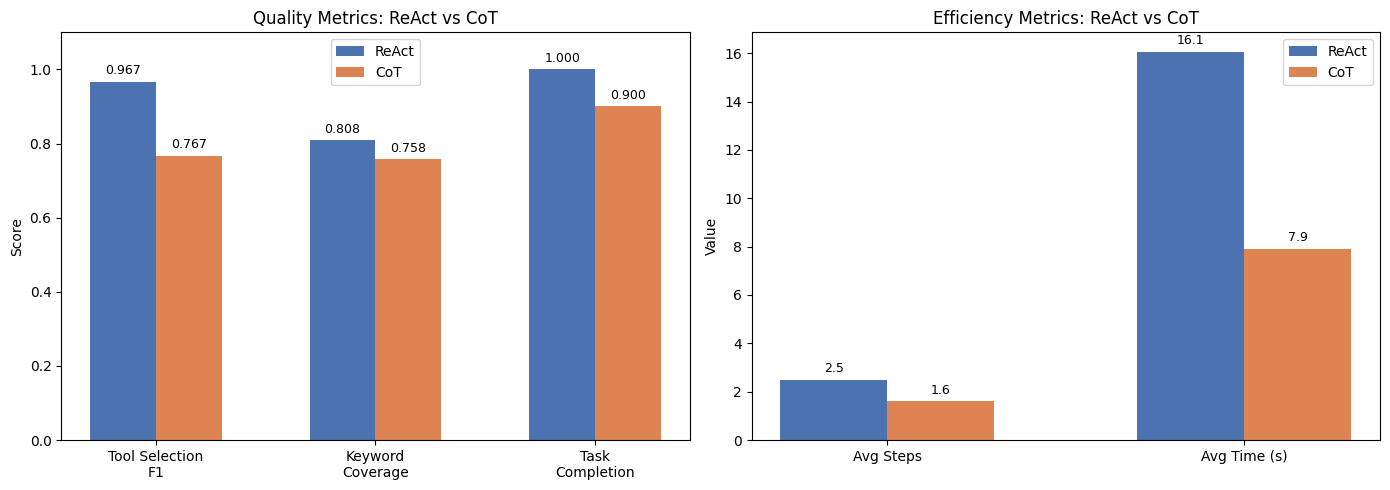

Chart saved to react_vs_cot_comparison.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["Tool Selection\nF1", "Keyword\nCoverage", "Task\nCompletion"]
react_vals = [df['react_tool_f1'].mean(), df['react_keywords'].mean(), (df['react_keywords'] > 0).mean()]
cot_vals = [df['cot_tool_f1'].mean(), df['cot_keywords'].mean(), (df['cot_keywords'] > 0).mean()]

x = np.arange(len(metrics))
width = 0.3

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Quality metrics
ax1 = axes[0]
ax1.bar(x - width/2, react_vals, width, label='ReAct', color='#4C72B0')
ax1.bar(x + width/2, cot_vals, width, label='CoT', color='#DD8452')
ax1.set_ylabel('Score')
ax1.set_title('Quality Metrics: ReAct vs CoT')
ax1.set_xticks(x)
ax1.set_xticklabels(metrics)
ax1.set_ylim(0, 1.1)
ax1.legend()
for i, (r, c) in enumerate(zip(react_vals, cot_vals)):
    ax1.text(i - width/2, r + 0.02, f'{r:.3f}', ha='center', fontsize=9)
    ax1.text(i + width/2, c + 0.02, f'{c:.3f}', ha='center', fontsize=9)

# Chart 2: Efficiency metrics
ax2 = axes[1]
eff_metrics = ["Avg Steps", "Avg Time (s)"]
react_eff = [df['react_steps'].mean(), df['react_time'].mean()]
cot_eff = [df['cot_steps'].mean(), df['cot_time'].mean()]
x2 = np.arange(len(eff_metrics))
ax2.bar(x2 - width/2, react_eff, width, label='ReAct', color='#4C72B0')
ax2.bar(x2 + width/2, cot_eff, width, label='CoT', color='#DD8452')
ax2.set_ylabel('Value')
ax2.set_title('Efficiency Metrics: ReAct vs CoT')
ax2.set_xticks(x2)
ax2.set_xticklabels(eff_metrics)
ax2.legend()
for i, (r, c) in enumerate(zip(react_eff, cot_eff)):
    ax2.text(i - width/2, r + 0.3, f'{r:.1f}', ha='center', fontsize=9)
    ax2.text(i + width/2, c + 0.3, f'{c:.1f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig("react_vs_cot_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to react_vs_cot_comparison.png")

# 6. Evaluation - Statistical Significance

In [ ]:
from scipy import stats

# Test if ReAct keyword coverage is significantly different from CoT
t_stat, p_value = stats.mannwhitneyu(
    df['react_keywords'].values,
    df['cot_keywords'].values,
    alternative='two-sided'
)
print(f"Keyword Coverage: U-statistic={t_stat:.3f}, p-value={p_value:.3f}")
print(f"Significant difference (p<0.05): {p_value < 0.05}")

t_stat2, p_value2 = stats.mannwhitneyu(
    df['react_tool_f1'].values,
    df['cot_tool_f1'].values,
    alternative='two-sided'
)
print(f"\nTool Selection F1: U-statistic={t_stat2:.3f}, p-value={p_value2:.3f}")
print(f"Significant difference (p<0.05): {p_value2 < 0.05}")

Keyword Coverage: U-statistic=51.500, p-value=0.932
Significant difference (p<0.05): False

Tool Selection F1: U-statistic=61.000, p-value=0.255
Significant difference (p<0.05): False


# 6. Evaluation - Ablation Study

In [ ]:
# Ablation: Remove quote_search tool
ALL_TOOLS_NO_QUOTES = [web_search, wikipedia_search, fetch_pdf, generate_citation]

def run_react_no_quotes(query, verbose=False):
    llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.0)
    agent = create_tool_calling_agent(llm=llm, tools=ALL_TOOLS_NO_QUOTES, prompt=prompt)
    executor = AgentExecutor(
        agent=agent, tools=ALL_TOOLS_NO_QUOTES, verbose=verbose,
        max_iterations=8, handle_parsing_errors=True,
        return_intermediate_steps=True,
    )
    result = executor.invoke({"input": query})
    steps = result.get("intermediate_steps", [])
    tools_used = [step[0].tool for step in steps]
    return {"output": result["output"], "num_steps": len(steps), "tools_used": tools_used}

# Test on quote-related questions only
quote_qs = [q for q in comparison_questions if "quote" in q["question"].lower()]

print("ABLATION: With vs Without quote_search")
print("=" * 60)
for q in quote_qs:
    print(f"\n{q['id']}: {q['question'][:50]}...")

    r_with = run_react(q["question"], verbose=False)
    r_without = run_react_no_quotes(q["question"], verbose=False)

    kw_with = keyword_cov(q["keywords"], r_with["output"])
    kw_without = keyword_cov(q["keywords"], r_without["output"])

    print(f"  WITH:    tools={r_with['tools_used']}, keyword_cov={kw_with:.2f}")
    print(f"  WITHOUT: tools={r_without['tools_used']}, keyword_cov={kw_without:.2f}")

ABLATION: With vs Without quote_search

q04: Find 3 quotes from the Transformer paper about why...
  WITH:    tools=['quote_search'], keyword_cov=1.00
  WITHOUT: tools=['web_search', 'fetch_pdf', 'web_search'], keyword_cov=1.00

q09: Find quotes from the Transformer paper about the t...
  WITH:    tools=['quote_search'], keyword_cov=0.33
  WITHOUT: tools=['web_search', 'web_search', 'fetch_pdf', 'fetch_pdf', 'fetch_pdf'], keyword_cov=0.33


# CoT vs React hotpot_qa

## Loading dataset

In [ ]:
# ============================================================
# HotpotQA Dataset Setup
# Download + inspect dataset for ReAct vs CoT evaluation
# ============================================================

!pip install datasets pandas -q

In [ ]:
from datasets import load_dataset
import pandas as pd
import json
from pprint import pprint

# HotpotQA has two common configs:
# - "distractor": includes distractor paragraphs, good for retrieval-style QA
# - "fullwiki": larger, closer to open-domain QA
#
# Start with distractor because it is easier/faster for evaluation.
hotpot = load_dataset("hotpot_qa", "distractor")

print(hotpot)

DatasetDict({
    train: Dataset({
        features: ['id', 'question', 'answer', 'type', 'level', 'supporting_facts', 'context'],
        num_rows: 90447
    })
    validation: Dataset({
        features: ['id', 'question', 'answer', 'type', 'level', 'supporting_facts', 'context'],
        num_rows: 7405
    })
})


In [ ]:
# Inspect splits and sizes
for split in hotpot:
    print(split, len(hotpot[split]))

train 90447
validation 7405


In [ ]:
# Look at one example
ex = hotpot["validation"][0]

print("Keys:")
print(ex.keys())

print("\nQuestion:")
print(ex["question"])

print("\nAnswer:")
print(ex["answer"])

print("\nType:")
print(ex["type"])

print("\nLevel:")
print(ex["level"])

print("\nSupporting facts:")
print(ex["supporting_facts"])



Keys:
dict_keys(['id', 'question', 'answer', 'type', 'level', 'supporting_facts', 'context'])

Question:
Were Scott Derrickson and Ed Wood of the same nationality?

Answer:
yes

Type:
comparison

Level:
hard

Supporting facts:
{'title': ['Scott Derrickson', 'Ed Wood'], 'sent_id': [0, 0]}


In [ ]:
# ============================================================
# Convert validation split into a pandas DataFrame
# ============================================================

rows = []

for ex in hotpot["validation"]:
    rows.append({
        "id": ex["id"],
        "question": ex["question"],
        "answer": ex["answer"],
        "type": ex["type"],
        "level": ex["level"],
        "supporting_facts": ex["supporting_facts"],
        "context": ex["context"],
    })

hotpot_df = pd.DataFrame(rows)

print(hotpot_df.shape)
hotpot_df.head()

(7405, 7)


,id,question,answer,type,level,supporting_facts,context
0,5a8b57f25542995d1e6f1371,Were Scott Derrickson and Ed Wood of the same ...,yes,comparison,hard,"{'title': ['Scott Derrickson', 'Ed Wood'], 'se...","{'title': ['Ed Wood (film)', 'Scott Derrickson..."
1,5a8c7595554299585d9e36b6,What government position was held by the woman...,Chief of Protocol,bridge,hard,"{'title': ['Kiss and Tell (1945 film)', 'Shirl...","{'title': ['Meet Corliss Archer', 'Shirley Tem..."
2,5a85ea095542994775f606a8,"What science fantasy young adult series, told ...",Animorphs,bridge,hard,"{'title': ['The Hork-Bajir Chronicles', 'The H...","{'title': ['Andre Norton Award', 'Victoria Han..."
3,5adbf0a255429947ff17385a,Are the Laleli Mosque and Esma Sultan Mansion ...,no,comparison,hard,"{'title': ['Laleli Mosque', 'Esma Sultan Mansi...",{'title': ['Esma Sultan (daughter of Abdülaziz...
4,5a8e3ea95542995a26add48d,"The director of the romantic comedy ""Big Stone...","Greenwich Village, New York City",bridge,hard,"{'title': ['Big Stone Gap (film)', 'Adriana Tr...",{'title': ['Just Another Romantic Wrestling Co...


In [ ]:
print("Question type counts:")
print(hotpot_df["type"].value_counts())

print("\nDifficulty level counts:")
print(hotpot_df["level"].value_counts())

Question type counts:
type
bridge        5918
comparison    1487
Name: count, dtype: int64

Difficulty level counts:
level
hard    7405
Name: count, dtype: int64


## Running 10 Questions

In [ ]:
# ============================================================
# Sample a manageable evaluation subset
# ============================================================

N = 10  # start small to avoid API/tool costs

benchmark_df = (
    hotpot_df
    .sample(n=N, random_state=42)
    .reset_index(drop=True)
)

benchmark_df[["id", "question", "answer", "type", "level"]]

,id,question,answer,type,level
0,5a7613c15542994ccc9186bf,VIVA Media AG changed it's name in 2004. What ...,Gesellschaft mit beschränkter Haftung,bridge,hard
1,5adf2fa35542993344016c11,Which of Jonny Craig and Pete Doherty has been...,"Jonny"" Craig",comparison,hard
2,5adfdef9554299025d62a36b,Where was the first governor after the The Mis...,"Bath, Maine",bridge,hard
3,5a7180205542994082a3e856,"The creator of ""Wallace and Gromit"" also creat...",Creature Comforts,bridge,hard
4,5a78bc6b554299148911f979,Woman's Era and Naj are what kind of magazines?,fortnightly women interest magazine,comparison,hard
5,5abdd0f15542991f6610604d,The Rome Protocols were signed by three Prime ...,a failed coup attempt,bridge,hard
6,5a8e27d45542995a26add46a,Jaclyn Stapp is married to the former frontman...,2004,bridge,hard
7,5a881d2355429938390d3eeb,If You Ever Get Lonely was covered by what Ly...,Love and Theft,bridge,hard
8,5ae4a1ef55429970de88d9e7,When was the Argentine former footballer whic...,2 March 1972,bridge,hard
9,5ae6f2a7554299572ea5464a,"Which character does this protagonist, who sec...",Tybalt,bridge,hard


In [ ]:
# ============================================================
# Convert HotpotQA rows into comparison_questions format
# ============================================================

hotpot_questions = []

for _, row in benchmark_df.iterrows():
    hotpot_questions.append({
        "id": row["id"],
        "question": row["question"],
        "gold_answer": row["answer"],
        "type": row["type"],
        "level": row["level"],
        "supporting_facts": row["supporting_facts"],
        "context": row["context"],
    })

hotpot_questions[0]

{'id': '5a7613c15542994ccc9186bf',
 'question': "VIVA Media AG changed it's name in 2004. What does their new acronym stand for?",
 'gold_answer': 'Gesellschaft mit beschränkter Haftung',
 'type': 'bridge',
 'level': 'hard',
 'supporting_facts': {'title': ['VIVA Media',
   'Gesellschaft mit beschränkter Haftung'],
  'sent_id': [0, 0]},
 'context': {'title': ['Constantin Medien',
   'VIVA Poland',
   'Viva (UK and Ireland)',
   'Blic',
   'Qontis',
   'VIVA Media',
   'ProSiebenSat.1 Media',
   'Gesellschaft mit beschränkter Haftung',
   'Mix Megapol',
   'John M. Keller'],
  'sentences': [['Constantin Medien AG (formerly EM.Entertainment and EM.TV & Merchandising AG, then EM.TV AG, and finally em.sport media ag) is a German media group, based in Ismaning near Munich, active in the area of sports, film and event marketing to medium-sized media companies.'],
   ['VIVA Polska (earlier "VIVApolska!")',
    ' is a Polish 24h music and entertainment channel from Viacom International Media Ne

In [ ]:
# ============================================================
# QA evaluation metrics: Exact Match and token F1
# ============================================================

import re
import string
from collections import Counter

def normalize_answer(s):
    """Lower text and remove punctuation, articles, and extra whitespace."""
    def remove_articles(text):
        return re.sub(r"\b(a|an|the)\b", " ", text)

    def white_space_fix(text):
        return " ".join(text.split())

    def remove_punc(text):
        exclude = set(string.punctuation)
        return "".join(ch for ch in text if ch not in exclude)

    def lower(text):
        return text.lower()

    return white_space_fix(remove_articles(remove_punc(lower(str(s)))))

def exact_match_score(prediction, ground_truth):
    return int(normalize_answer(prediction) == normalize_answer(ground_truth))

def f1_score(prediction, ground_truth):
    pred_tokens = normalize_answer(prediction).split()
    gold_tokens = normalize_answer(ground_truth).split()

    if len(pred_tokens) == 0 and len(gold_tokens) == 0:
        return 1.0
    if len(pred_tokens) == 0 or len(gold_tokens) == 0:
        return 0.0

    common = Counter(pred_tokens) & Counter(gold_tokens)
    num_same = sum(common.values())

    if num_same == 0:
        return 0.0

    precision = num_same / len(pred_tokens)
    recall = num_same / len(gold_tokens)

    return 2 * precision * recall / (precision + recall)

In [ ]:

# ============================================================
# FIXED ReAct prompt for HotpotQA
# Escapes JSON braces for ChatPromptTemplate
# ============================================================

from langchain_classic.agents import AgentExecutor, create_tool_calling_agent
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.messages import HumanMessage, SystemMessage
import json
import re


REACT_HOTPOT_PROMPT = ChatPromptTemplate.from_messages([
    ("system", """You are a factual multi-hop question answering agent.

You have access to tools:
- web_search
- wikipedia_search
- fetch_pdf
- generate_citation
- quote_search
- summarize_active_document
- find_paper_quotes

Your job:
1. Answer HotpotQA-style factual questions.
2. Use tools to gather evidence before answering.
3. For multi-hop questions, break the question into smaller lookup steps.
4. Use the observations from tools to decide the next action.
5. Stop once you have enough evidence.
6. Return only valid JSON in this exact format:
{{"answer": "short final answer"}}

Important rules:
- Do not include sources in the final answer.
- Do not include explanation in the final answer.
- Do not include markdown.
- The answer should be as short as possible.
- If the question asks for a person, place, date, title, year, or object, return only that.
- If unsure, still give the best short answer supported by tool results.
"""),
    ("human", "{input}"),
    MessagesPlaceholder("agent_scratchpad"),
])


def run_react_hotpot(query, model_name="gpt-4o-mini", temperature=0.0,
                     max_iterations=6, verbose=False):
    llm = ChatOpenAI(model=model_name, temperature=temperature)

    agent = create_tool_calling_agent(
        llm,
        ALL_TOOLS,
        REACT_HOTPOT_PROMPT
    )

    executor = AgentExecutor(
        agent=agent,
        tools=ALL_TOOLS,
        verbose=verbose,
        max_iterations=max_iterations,
        return_intermediate_steps=True,
        handle_parsing_errors=True,
    )

    result = executor.invoke({"input": query})

    steps = result.get("intermediate_steps", [])
    tools_used = []

    for step in steps:
        try:
            tools_used.append(step[0].tool)
        except Exception:
            pass

    return {
        "output": result.get("output", ""),
        "intermediate_steps": steps,
        "num_steps": len(steps),
        "tools_used": tools_used,
    }


# ----------------------------
# CoT prompt
# ----------------------------

COT_HOTPOT_SYSTEM_PROMPT = """You are a factual multi-hop question answering agent.

You have access to tools:
1. web_search(query) - Search the web for factual/current information.
2. wikipedia_search(query) - Look up background context on Wikipedia.
3. fetch_pdf(url) - Download and extract text from a PDF.
4. generate_citation(title, authors, year, url, source_type) - Format a citation.
5. quote_search(query) - Retrieve exact quotes from the active document.
6. summarize_active_document(query) - Summarize the active document.
7. find_paper_quotes(query) - Find sources and verified quotes for citation claims.

Your job:
- Answer HotpotQA-style factual multi-hop questions.
- Always use at least one search tool for factual questions.
- If the question compares two entities, search for both entities when useful.
- If the question requires a bridge entity, search for the first entity, then search for the bridge entity.
- Plan the tool calls upfront before seeing observations.
- Return only a JSON plan.

Valid tool names:
web_search, wikipedia_search, fetch_pdf, generate_citation, quote_search, summarize_active_document, find_paper_quotes

Return only valid JSON in this exact format:
{
  "plan": [
    {"tool": "web_search", "input": {"query": "focused search query"}}
  ]
}

Do not answer the question directly in this planning step.
Do not return an empty plan for factual HotpotQA questions.
"""


def run_cot_hotpot(query, model_name="gpt-4o-mini", temperature=0.0, verbose=False):
    """
    CoT-style baseline:
    - Makes a fixed tool-use plan upfront.
    - Executes the plan.
    - Synthesizes a JSON short answer from the collected results.
    """
    llm = ChatOpenAI(model=model_name, temperature=temperature)
    tool_map = {t.name: t for t in ALL_TOOLS}

    # Step 1: generate fixed plan
    if verbose:
        print("[CoT] Generating fixed research plan...")

    plan_response = llm.invoke([
        SystemMessage(content=COT_HOTPOT_SYSTEM_PROMPT),
        HumanMessage(content=f"Question: {query}")
    ])

    plan_text = plan_response.content.strip()

    try:
        if "```json" in plan_text:
            plan_text = plan_text.split("```json", 1)[1].split("```", 1)[0].strip()
        elif "```" in plan_text:
            plan_text = plan_text.split("```", 1)[1].split("```", 1)[0].strip()

        plan = json.loads(plan_text)

    except Exception:
        # Safe fallback: one search query
        plan = {
            "plan": [
                {"tool": "web_search", "input": {"query": query}}
            ]
        }

    # Force at least one tool call for fair comparison
    if not plan.get("plan"):
        plan = {
            "plan": [
                {"tool": "web_search", "input": {"query": query}}
            ]
        }

    if verbose:
        print("[CoT] Plan:")
        print(json.dumps(plan, indent=2))

    # Step 2: execute fixed plan
    tool_results = []
    tools_used = []

    for i, step in enumerate(plan.get("plan", []), 1):
        tool_name = step.get("tool", "")
        tool_input = step.get("input", {})

        if tool_name not in tool_map:
            continue

        if verbose:
            print(f"[CoT] Calling {tool_name}: {tool_input}")

        try:
            tool_fn = tool_map[tool_name]

            if isinstance(tool_input, dict) and len(tool_input) == 1:
                result = tool_fn.invoke(list(tool_input.values())[0])
            elif isinstance(tool_input, dict):
                result = tool_fn.invoke(tool_input)
            else:
                result = tool_fn.invoke(str(tool_input))

            tool_results.append({
                "tool": tool_name,
                "input": tool_input,
                "result": result
            })
            tools_used.append(tool_name)

        except Exception as e:
            tool_results.append({
                "tool": tool_name,
                "input": tool_input,
                "result": f"ERROR: {e}"
            })

    # Step 3: synthesize short JSON answer
    results_text = "\n\n".join([
        f"=== {r['tool']}({r['input']}) ===\n{r['result']}"
        for r in tool_results
    ])

    synthesis_prompt = f"""
Question:
{query}

Tool results:
{results_text}

Return only valid JSON in this exact format:
{{"answer": "short final answer"}}

Rules:
- Do not include sources.
- Do not include explanation.
- Do not include markdown.
- The answer should be as short as possible.
- If the answer is a date, preserve the date as stated in the evidence when possible.
"""

    synthesis = llm.invoke([
        SystemMessage(content="You answer factual questions using only the provided tool results."),
        HumanMessage(content=synthesis_prompt)
    ])

    return {
        "output": synthesis.content,
        "plan": plan,
        "tool_results": tool_results,
        "num_steps": len(tool_results),
        "tools_used": tools_used,
    }

In [ ]:
# ============================================================
# Run fair ReAct vs CoT HotpotQA evaluation
# ============================================================

import time
import pandas as pd
import json
import re

# Optional: use smaller subset while debugging
# hotpot_questions = hotpot_questions[:10]

def clean_extracted_answer(ans: str) -> str:
    ans = str(ans).strip()
    ans = ans.replace("**", "")

    ans = re.sub(r"https?://\S+", "", ans)
    ans = re.sub(r"\s*\[[^\]]*\]\s*$", "", ans)
    ans = re.sub(r"\s*\([^)]*https?://[^)]*\)\s*$", "", ans)

    ans = re.sub(r"^(therefore|so|thus|hence),?\s+", "", ans, flags=re.IGNORECASE)
    ans = re.sub(r"^the answer is\s+", "", ans, flags=re.IGNORECASE)

    ans = ans.strip(" .,:;")
    return ans


def extract_json_answer(output: str) -> str:
    text = str(output).strip()

    if not text:
        return ""

    if "```json" in text:
        text = text.split("```json", 1)[1].split("```", 1)[0].strip()
    elif "```" in text:
        text = text.split("```", 1)[1].split("```", 1)[0].strip()

    try:
        parsed = json.loads(text)
        if isinstance(parsed, dict) and "answer" in parsed:
            return clean_extracted_answer(parsed["answer"])
    except Exception:
        pass

    match = re.search(
        r'"answer"\s*:\s*"([^"]*)"',
        text,
        flags=re.DOTALL
    )
    if match:
        return clean_extracted_answer(match.group(1))

    return clean_extracted_answer(text)


rows = []

for i, q in enumerate(hotpot_questions, 1):
    print(f"\n{'='*80}")
    print(f"[{i}/{len(hotpot_questions)}] {q['question']}")
    print(f"Gold: {q['gold_answer']}")
    print("="*80)

    question = q["question"]

    # -------------------------
    # ReAct
    # -------------------------
    t0 = time.time()

    try:
        react_result = run_react_hotpot(
            question,
            verbose=False,
            max_iterations=6
        )
        react_output = react_result.get("output", "")
        react_tools = react_result.get("tools_used", [])
        react_steps = react_result.get("num_steps", 0)

    except Exception as e:
        react_output = f"ERROR: {e}"
        react_tools = []
        react_steps = 0

    react_time = round(time.time() - t0, 2)
    react_pred = extract_json_answer(react_output)

    # -------------------------
    # CoT
    # -------------------------
    t0 = time.time()

    try:
        cot_result = run_cot_hotpot(
            question,
            verbose=False
        )
        cot_output = cot_result.get("output", "")
        cot_tools = cot_result.get("tools_used", [])
        cot_steps = cot_result.get("num_steps", 0)

    except Exception as e:
        cot_output = f"ERROR: {e}"
        cot_tools = []
        cot_steps = 0

    cot_time = round(time.time() - t0, 2)
    cot_pred = extract_json_answer(cot_output)

    # -------------------------
    # Store result
    # -------------------------
    row = {
        "id": q["id"],
        "question": q["question"],
        "gold_answer": q["gold_answer"],
        "type": q["type"],
        "level": q["level"],

        "react_output": react_output,
        "react_pred": react_pred,
        "react_em": exact_match_score(react_pred, q["gold_answer"]),
        "react_f1": f1_score(react_pred, q["gold_answer"]),
        "react_tools": str(react_tools),
        "react_steps": react_steps,
        "react_time": react_time,

        "cot_output": cot_output,
        "cot_pred": cot_pred,
        "cot_em": exact_match_score(cot_pred, q["gold_answer"]),
        "cot_f1": f1_score(cot_pred, q["gold_answer"]),
        "cot_tools": str(cot_tools),
        "cot_steps": cot_steps,
        "cot_time": cot_time,
    }

    rows.append(row)

    print("\nReAct pred:", react_pred)
    print("ReAct EM/F1:", row["react_em"], round(row["react_f1"], 3))
    print("ReAct tools:", react_tools)
    print("ReAct steps/time:", react_steps, react_time)

    print("\nCoT pred:", cot_pred)
    print("CoT EM/F1:", row["cot_em"], round(row["cot_f1"], 3))
    print("CoT tools:", cot_tools)
    print("CoT steps/time:", cot_steps, cot_time)

hotpot_eval_df = pd.DataFrame(rows)
hotpot_eval_df.head()


[1/10] VIVA Media AG changed it's name in 2004. What does their new acronym stand for?
Gold: Gesellschaft mit beschränkter Haftung

ReAct pred: Agent stopped due to max iterations
ReAct EM/F1: 0 0.0
ReAct tools: ['wikipedia_search', 'web_search', 'web_search', 'web_search', 'web_search', 'web_search']
ReAct steps/time: 6 12.3

CoT pred: VIVA Media AG stands for "VIVA" after the name change in 2004
CoT EM/F1: 0 0.0
CoT tools: ['web_search']
CoT steps/time: 1 2.43

[2/10] Which of Jonny Craig and Pete Doherty has been a member of more bands ?
Gold: Jonny" Craig

ReAct pred: Jonny Craig
ReAct EM/F1: 1 1.0
ReAct tools: ['wikipedia_search', 'wikipedia_search', 'web_search', 'web_search', 'web_search', 'web_search', 'web_search', 'web_search', 'web_search', 'web_search']
ReAct steps/time: 10 18.03

CoT pred: Jonny Craig
CoT EM/F1: 1 1.0
CoT tools: ['web_search', 'web_search']
CoT steps/time: 2 4.52

[3/10] Where was the first governor after the The Missouri Compromise from?
Gold: Bath, Main

,id,question,gold_answer,type,level,react_output,react_pred,react_em,react_f1,react_tools,react_steps,react_time,cot_output,cot_pred,cot_em,cot_f1,cot_tools,cot_steps,cot_time
0,5a7613c15542994ccc9186bf,VIVA Media AG changed it's name in 2004. What ...,Gesellschaft mit beschränkter Haftung,bridge,hard,Agent stopped due to max iterations.,Agent stopped due to max iterations,0,0.000,"['wikipedia_search', 'web_search', 'web_search...",6,12.30,"{""answer"":""VIVA Media AG stands for \""VIVA\"" a...","VIVA Media AG stands for ""VIVA"" after the name...",0,0.000000,['web_search'],1,2.43
1,5adf2fa35542993344016c11,Which of Jonny Craig and Pete Doherty has been...,"Jonny"" Craig",comparison,hard,"{""answer"":""Jonny Craig""}",Jonny Craig,1,1.000,"['wikipedia_search', 'wikipedia_search', 'web_...",10,18.03,"{""answer"": ""Jonny Craig""}",Jonny Craig,1,1.000000,"['web_search', 'web_search']",2,4.52
2,5adfdef9554299025d62a36b,Where was the first governor after the The Mis...,"Bath, Maine",bridge,hard,"{""answer"": ""Lancaster, Pennsylvania""}","Lancaster, Pennsylvania",0,0.000,"['wikipedia_search', 'web_search', 'web_search...",4,9.10,"{""answer"": ""Claiborne Fox Jackson from Kentucky""}",Claiborne Fox Jackson from Kentucky,0,0.000000,['web_search'],1,1.69
3,5a7180205542994082a3e856,"The creator of ""Wallace and Gromit"" also creat...",Creature Comforts,bridge,hard,"{""answer"": ""Creature Comforts""}",Creature Comforts,1,1.000,"['wikipedia_search', 'web_search', 'web_search']",3,7.68,"{""answer"": ""Creature Comforts""}",Creature Comforts,1,1.000000,['web_search'],1,3.87
4,5a78bc6b554299148911f979,Woman's Era and Naj are what kind of magazines?,fortnightly women interest magazine,comparison,hard,"{""answer"":""Woman's Era is a women's magazine, ...","Woman's Era is a women's magazine, and Naj is ...",0,0.125,"['wikipedia_search', 'wikipedia_search', 'web_...",4,5.66,"{""answer"": ""Woman's Era is a women's magazine;...",Woman's Era is a women's magazine; Naj is a li...,0,0.133333,"['web_search', 'web_search']",2,3.87


In [ ]:
# ============================================================
# Summary: fair HotpotQA ReAct vs CoT
# ============================================================

summary = pd.DataFrame({
    "Metric": [
        "Exact Match",
        "Token F1",
        "Avg Steps",
        "Avg Time (s)"
    ],
    "ReAct": [
        hotpot_eval_df["react_em"].mean(),
        hotpot_eval_df["react_f1"].mean(),
        hotpot_eval_df["react_steps"].mean(),
        hotpot_eval_df["react_time"].mean(),
    ],
    "CoT": [
        hotpot_eval_df["cot_em"].mean(),
        hotpot_eval_df["cot_f1"].mean(),
        hotpot_eval_df["cot_steps"].mean(),
        hotpot_eval_df["cot_time"].mean(),
    ]
})

summary

,Metric,ReAct,CoT
0,Exact Match,0.4000,0.300000
1,Token F1,0.5125,0.313333
2,Avg Steps,4.9000,1.200000
3,Avg Time (s),9.9010,2.732000


In [ ]:
# ============================================================
# Build N=100 HotpotQA evaluation subset
# ============================================================

N = 100

benchmark_df = (
    hotpot_df
    .sample(n=N, random_state=42)
    .reset_index(drop=True)
)

hotpot_questions_100 = []

for _, row in benchmark_df.iterrows():
    hotpot_questions_100.append({
        "id": row["id"],
        "question": row["question"],
        "gold_answer": row["answer"],
        "type": row["type"],
        "level": row["level"],
        "supporting_facts": row["supporting_facts"],
        "context": row["context"],
    })

print(f"Prepared {len(hotpot_questions_100)} HotpotQA questions.")
benchmark_df[["id", "question", "answer", "type", "level"]].head()

Prepared 100 HotpotQA questions.


,id,question,answer,type,level
0,5a7613c15542994ccc9186bf,VIVA Media AG changed it's name in 2004. What ...,Gesellschaft mit beschränkter Haftung,bridge,hard
1,5adf2fa35542993344016c11,Which of Jonny Craig and Pete Doherty has been...,"Jonny"" Craig",comparison,hard
2,5adfdef9554299025d62a36b,Where was the first governor after the The Mis...,"Bath, Maine",bridge,hard
3,5a7180205542994082a3e856,"The creator of ""Wallace and Gromit"" also creat...",Creature Comforts,bridge,hard
4,5a78bc6b554299148911f979,Woman's Era and Naj are what kind of magazines?,fortnightly women interest magazine,comparison,hard


## Running 100 Questions

In [ ]:
# ============================================================
# Run fair ReAct vs CoT HotpotQA evaluation for N=100
# ============================================================

import time
import pandas as pd
import json
import re

rows = []

for i, q in enumerate(hotpot_questions_100, 1):
    print(f"\n{'='*80}")
    print(f"[{i}/{len(hotpot_questions_100)}] {q['question']}")
    print(f"Gold: {q['gold_answer']}")
    print("="*80)

    question = q["question"]

    # -------------------------
    # ReAct
    # -------------------------
    t0 = time.time()

    try:
        react_result = run_react_hotpot(
            question,
            verbose=False,
            max_iterations=6
        )
        react_output = react_result.get("output", "")
        react_tools = react_result.get("tools_used", [])
        react_steps = react_result.get("num_steps", 0)

    except Exception as e:
        react_output = f"ERROR: {e}"
        react_tools = []
        react_steps = 0

    react_time = round(time.time() - t0, 2)
    react_pred = extract_json_answer(react_output)

    # -------------------------
    # CoT
    # -------------------------
    t0 = time.time()

    try:
        cot_result = run_cot_hotpot(
            question,
            verbose=False
        )
        cot_output = cot_result.get("output", "")
        cot_tools = cot_result.get("tools_used", [])
        cot_steps = cot_result.get("num_steps", 0)

    except Exception as e:
        cot_output = f"ERROR: {e}"
        cot_tools = []
        cot_steps = 0

    cot_time = round(time.time() - t0, 2)
    cot_pred = extract_json_answer(cot_output)

    # -------------------------
    # Store result
    # -------------------------
    row = {
        "id": q["id"],
        "question": q["question"],
        "gold_answer": q["gold_answer"],
        "type": q["type"],
        "level": q["level"],

        "react_output": react_output,
        "react_pred": react_pred,
        "react_em": exact_match_score(react_pred, q["gold_answer"]),
        "react_f1": f1_score(react_pred, q["gold_answer"]),
        "react_tools": str(react_tools),
        "react_steps": react_steps,
        "react_time": react_time,
        "react_max_iter_fail": int("Agent stopped due to max iterations" in str(react_output)),

        "cot_output": cot_output,
        "cot_pred": cot_pred,
        "cot_em": exact_match_score(cot_pred, q["gold_answer"]),
        "cot_f1": f1_score(cot_pred, q["gold_answer"]),
        "cot_tools": str(cot_tools),
        "cot_steps": cot_steps,
        "cot_time": cot_time,
        "cot_max_iter_fail": int("Agent stopped due to max iterations" in str(cot_output)),
    }

    rows.append(row)

    print("\nReAct pred:", react_pred)
    print("ReAct EM/F1:", row["react_em"], round(row["react_f1"], 3))
    print("ReAct tools:", react_tools)
    print("ReAct steps/time:", react_steps, react_time)

    print("\nCoT pred:", cot_pred)
    print("CoT EM/F1:", row["cot_em"], round(row["cot_f1"], 3))
    print("CoT tools:", cot_tools)
    print("CoT steps/time:", cot_steps, cot_time)

    # Save checkpoint every 10 questions
    if i % 10 == 0:
        checkpoint_df = pd.DataFrame(rows)
        checkpoint_df.to_csv("hotpotqa_react_vs_cot_n100_checkpoint.csv", index=False)
        print(f"\nCheckpoint saved at {i} questions.")

hotpot_eval_df_100 = pd.DataFrame(rows)

hotpot_eval_df_100.to_csv("hotpotqa_react_vs_cot_n100_results.csv", index=False)

print("\nSaved final results to hotpotqa_react_vs_cot_n100_results.csv")
hotpot_eval_df_100.head()


[1/100] VIVA Media AG changed it's name in 2004. What does their new acronym stand for?
Gold: Gesellschaft mit beschränkter Haftung

ReAct pred: Agent stopped due to max iterations
ReAct EM/F1: 0 0.0
ReAct tools: ['wikipedia_search', 'web_search', 'web_search', 'web_search', 'web_search', 'web_search']
ReAct steps/time: 6 13.7

CoT pred: VIVA Media AG stands for VIVA
CoT EM/F1: 0 0.0
CoT tools: ['web_search']
CoT steps/time: 1 2.06

[2/100] Which of Jonny Craig and Pete Doherty has been a member of more bands ?
Gold: Jonny" Craig

ReAct pred: Pete Doherty
ReAct EM/F1: 0 0.0
ReAct tools: ['wikipedia_search', 'wikipedia_search', 'web_search', 'web_search', 'web_search', 'web_search', 'web_search', 'web_search']
ReAct steps/time: 8 15.08

CoT pred: Jonny Craig
CoT EM/F1: 1 1.0
CoT tools: ['web_search', 'web_search']
CoT steps/time: 2 3.57

[3/100] Where was the first governor after the The Missouri Compromise from?
Gold: Bath, Maine

ReAct pred: Lancaster, Pennsylvania
ReAct EM/F1: 0 0.0

,id,question,gold_answer,type,level,react_output,react_pred,react_em,react_f1,react_tools,...,react_time,react_max_iter_fail,cot_output,cot_pred,cot_em,cot_f1,cot_tools,cot_steps,cot_time,cot_max_iter_fail
0,5a7613c15542994ccc9186bf,VIVA Media AG changed it's name in 2004. What ...,Gesellschaft mit beschränkter Haftung,bridge,hard,Agent stopped due to max iterations.,Agent stopped due to max iterations,0,0.0,"['wikipedia_search', 'web_search', 'web_search...",...,13.70,1,"{""answer"": ""VIVA Media AG stands for VIVA.""}",VIVA Media AG stands for VIVA,0,0.000000,['web_search'],1,2.06,0
1,5adf2fa35542993344016c11,Which of Jonny Craig and Pete Doherty has been...,"Jonny"" Craig",comparison,hard,"{""answer"":""Pete Doherty""}",Pete Doherty,0,0.0,"['wikipedia_search', 'wikipedia_search', 'web_...",...,15.08,0,"{""answer"": ""Jonny Craig""}",Jonny Craig,1,1.000000,"['web_search', 'web_search']",2,3.57,0
2,5adfdef9554299025d62a36b,Where was the first governor after the The Mis...,"Bath, Maine",bridge,hard,"{""answer"": ""Lancaster, Pennsylvania""}","Lancaster, Pennsylvania",0,0.0,"['wikipedia_search', 'web_search']",...,4.77,0,"{""answer"": ""St. Louis""}",St. Louis,0,0.000000,['web_search'],1,3.78,0
3,5a7180205542994082a3e856,"The creator of ""Wallace and Gromit"" also creat...",Creature Comforts,bridge,hard,"{""answer"":""Creature Comforts""}",Creature Comforts,1,1.0,"['wikipedia_search', 'web_search', 'wikipedia_...",...,13.17,0,"{""answer"": ""Creature Comforts""}",Creature Comforts,1,1.000000,['web_search'],1,3.80,0
4,5a78bc6b554299148911f979,Woman's Era and Naj are what kind of magazines?,fortnightly women interest magazine,comparison,hard,"{""answer"":""Woman's Era is a women's lifestyle ...","Woman's Era is a women's lifestyle magazine, w...",0,0.1,"['wikipedia_search', 'wikipedia_search', 'web_...",...,10.79,0,"{""answer"": ""Woman's Era is a women's magazine;...",Woman's Era is a women's magazine; Naj is a wo...,0,0.133333,"['web_search', 'web_search']",2,3.89,0


In [ ]:
# ============================================================
# Summary table for N=100
# ============================================================

summary_100 = pd.DataFrame({
    "Metric": [
        "Exact Match",
        "Token F1",
        "Avg Steps",
        "Avg Time (s)",
        "Max-Iteration Failure Rate"
    ],
    "ReAct": [
        hotpot_eval_df_100["react_em"].mean(),
        hotpot_eval_df_100["react_f1"].mean(),
        hotpot_eval_df_100["react_steps"].mean(),
        hotpot_eval_df_100["react_time"].mean(),
        hotpot_eval_df_100["react_max_iter_fail"].mean(),
    ],
    "CoT": [
        hotpot_eval_df_100["cot_em"].mean(),
        hotpot_eval_df_100["cot_f1"].mean(),
        hotpot_eval_df_100["cot_steps"].mean(),
        hotpot_eval_df_100["cot_time"].mean(),
        hotpot_eval_df_100["cot_max_iter_fail"].mean(),
    ]
})

summary_100.to_csv("hotpotqa_react_vs_cot_n100_summary.csv", index=False)
summary_100

,Metric,ReAct,CoT
0,Exact Match,0.370000,0.390000
1,Token F1,0.469365,0.486965
2,Avg Steps,4.440000,1.230000
3,Avg Time (s),8.750700,2.399300
4,Max-Iteration Failure Rate,0.270000,0.000000


In [ ]:
# ============================================================
# Statistical significance testing: ReAct vs CoT
# ============================================================

import numpy as np
from scipy import stats

df_sig = hotpot_eval_df_100.copy()

# Paired differences
em_diff = df_sig["react_em"] - df_sig["cot_em"]
f1_diff = df_sig["react_f1"] - df_sig["cot_f1"]
steps_diff = df_sig["react_steps"] - df_sig["cot_steps"]
time_diff = df_sig["react_time"] - df_sig["cot_time"]

print("="*80)
print("Mean differences: ReAct - CoT")
print("="*80)
print(f"Exact Match diff: {em_diff.mean():.4f}")
print(f"Token F1 diff:    {f1_diff.mean():.4f}")
print(f"Steps diff:       {steps_diff.mean():.4f}")
print(f"Time diff:        {time_diff.mean():.4f}")


# ------------------------------------------------------------
# 1. McNemar test for paired Exact Match
# ------------------------------------------------------------
# b = ReAct correct, CoT wrong
# c = ReAct wrong, CoT correct

b = int(((df_sig["react_em"] == 1) & (df_sig["cot_em"] == 0)).sum())
c = int(((df_sig["react_em"] == 0) & (df_sig["cot_em"] == 1)).sum())

print("\n" + "="*80)
print("McNemar test for Exact Match")
print("="*80)
print(f"ReAct correct / CoT wrong: {b}")
print(f"ReAct wrong / CoT correct: {c}")

# Exact binomial version of McNemar
if b + c > 0:
    mcnemar_p = stats.binomtest(
        k=min(b, c),
        n=b + c,
        p=0.5,
        alternative="two-sided"
    ).pvalue
else:
    mcnemar_p = 1.0

print(f"McNemar exact p-value: {mcnemar_p:.4f}")
print(f"Significant at p < 0.05: {mcnemar_p < 0.05}")


# ------------------------------------------------------------
# 2. Wilcoxon signed-rank test for paired F1
# ------------------------------------------------------------

print("\n" + "="*80)
print("Wilcoxon signed-rank test for Token F1")
print("="*80)

nonzero_f1_diff = f1_diff[f1_diff != 0]

if len(nonzero_f1_diff) > 0:
    wilcoxon_f1 = stats.wilcoxon(
        df_sig["react_f1"],
        df_sig["cot_f1"],
        zero_method="wilcox",
        alternative="two-sided"
    )
    print(f"Wilcoxon statistic: {wilcoxon_f1.statistic:.4f}")
    print(f"Wilcoxon p-value:   {wilcoxon_f1.pvalue:.4f}")
    print(f"Significant at p < 0.05: {wilcoxon_f1.pvalue < 0.05}")
else:
    print("All paired F1 differences are zero; Wilcoxon test not applicable.")


# ------------------------------------------------------------
# 3. Wilcoxon signed-rank tests for efficiency metrics
# ------------------------------------------------------------

print("\n" + "="*80)
print("Wilcoxon signed-rank tests for efficiency")
print("="*80)

if (steps_diff != 0).sum() > 0:
    wilcoxon_steps = stats.wilcoxon(
        df_sig["react_steps"],
        df_sig["cot_steps"],
        zero_method="wilcox",
        alternative="two-sided"
    )
    print(f"Steps p-value: {wilcoxon_steps.pvalue:.4f}")
else:
    print("All step differences are zero; steps test not applicable.")

if (time_diff != 0).sum() > 0:
    wilcoxon_time = stats.wilcoxon(
        df_sig["react_time"],
        df_sig["cot_time"],
        zero_method="wilcox",
        alternative="two-sided"
    )
    print(f"Time p-value:  {wilcoxon_time.pvalue:.4f}")
else:
    print("All time differences are zero; time test not applicable.")

Mean differences: ReAct - CoT
Exact Match diff: -0.0200
Token F1 diff:    -0.0176
Steps diff:       3.2100
Time diff:        6.3514

McNemar test for Exact Match
ReAct correct / CoT wrong: 8
ReAct wrong / CoT correct: 10
McNemar exact p-value: 0.8145
Significant at p < 0.05: False

Wilcoxon signed-rank test for Token F1
Wilcoxon statistic: 257.5000
Wilcoxon p-value:   0.6788
Significant at p < 0.05: False

Wilcoxon signed-rank tests for efficiency
Steps p-value: 0.0000
Time p-value:  0.0000


In [ ]:
# ============================================================
# Bootstrap confidence intervals for ReAct - CoT differences
# ============================================================

import numpy as np

def bootstrap_ci(diff_values, n_boot=10000, ci=95, seed=42):
    rng = np.random.default_rng(seed)
    diff_values = np.array(diff_values)

    boot_means = []

    for _ in range(n_boot):
        sample = rng.choice(diff_values, size=len(diff_values), replace=True)
        boot_means.append(sample.mean())

    lower = np.percentile(boot_means, (100 - ci) / 2)
    upper = np.percentile(boot_means, 100 - (100 - ci) / 2)

    return diff_values.mean(), lower, upper

metrics_for_ci = {
    "Exact Match": em_diff,
    "Token F1": f1_diff,
    "Steps": steps_diff,
    "Time": time_diff,
}

ci_rows = []

for metric, diffs in metrics_for_ci.items():
    mean_diff, lower, upper = bootstrap_ci(diffs)
    ci_rows.append({
        "metric": metric,
        "mean_diff_react_minus_cot": mean_diff,
        "ci_lower_95": lower,
        "ci_upper_95": upper,
    })

ci_df = pd.DataFrame(ci_rows)
ci_df

,metric,mean_diff_react_minus_cot,ci_lower_95,ci_upper_95
0,Exact Match,-0.0200,-0.100000,0.060000
1,Token F1,-0.0176,-0.096904,0.062277
2,Steps,3.2100,2.830000,3.590000
3,Time,6.3514,5.565977,7.165622


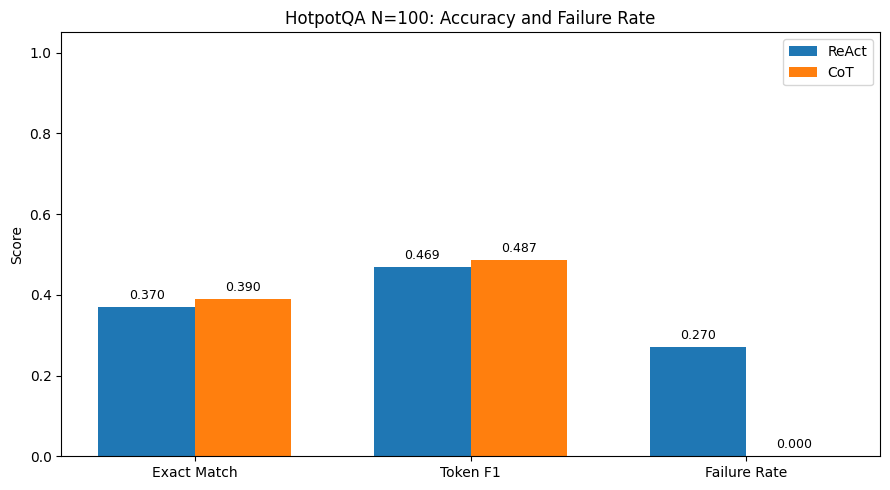

In [ ]:
# ============================================================
# Graph 1: Main performance and efficiency comparison
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

metrics = ["Exact Match", "Token F1", "Failure Rate"]
react_vals = [
    hotpot_eval_df_100["react_em"].mean(),
    hotpot_eval_df_100["react_f1"].mean(),
    hotpot_eval_df_100["react_max_iter_fail"].mean(),
]
cot_vals = [
    hotpot_eval_df_100["cot_em"].mean(),
    hotpot_eval_df_100["cot_f1"].mean(),
    hotpot_eval_df_100["cot_max_iter_fail"].mean(),
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - width/2, react_vals, width, label="ReAct")
plt.bar(x + width/2, cot_vals, width, label="CoT")

plt.ylabel("Score")
plt.title("HotpotQA N=100: Accuracy and Failure Rate")
plt.xticks(x, metrics)
plt.ylim(0, 1.05)
plt.legend()

for i, (r, c) in enumerate(zip(react_vals, cot_vals)):
    plt.text(i - width/2, r + 0.02, f"{r:.3f}", ha="center", fontsize=9)
    plt.text(i + width/2, c + 0.02, f"{c:.3f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("hotpotqa_n100_accuracy_failure.png", dpi=150, bbox_inches="tight")
plt.show()

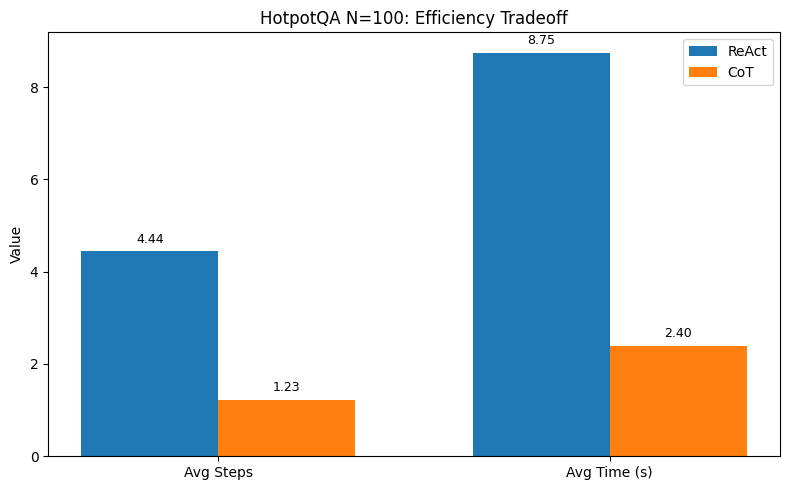

In [ ]:
# ============================================================
# Graph 2: Efficiency comparison
# ============================================================

eff_metrics = ["Avg Steps", "Avg Time (s)"]
react_eff = [
    hotpot_eval_df_100["react_steps"].mean(),
    hotpot_eval_df_100["react_time"].mean(),
]
cot_eff = [
    hotpot_eval_df_100["cot_steps"].mean(),
    hotpot_eval_df_100["cot_time"].mean(),
]

x = np.arange(len(eff_metrics))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, react_eff, width, label="ReAct")
plt.bar(x + width/2, cot_eff, width, label="CoT")

plt.ylabel("Value")
plt.title("HotpotQA N=100: Efficiency Tradeoff")
plt.xticks(x, eff_metrics)
plt.legend()

for i, (r, c) in enumerate(zip(react_eff, cot_eff)):
    plt.text(i - width/2, r + max(react_eff + cot_eff) * 0.02, f"{r:.2f}", ha="center", fontsize=9)
    plt.text(i + width/2, c + max(react_eff + cot_eff) * 0.02, f"{c:.2f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("hotpotqa_n100_efficiency.png", dpi=150, bbox_inches="tight")
plt.show()

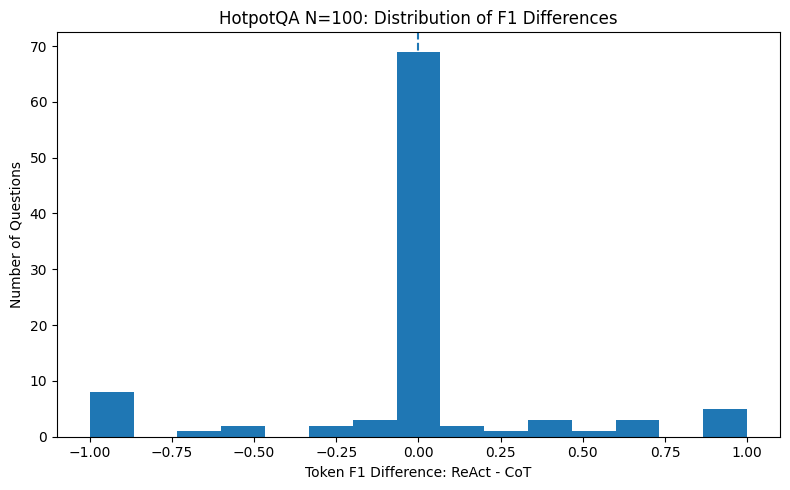

In [ ]:
# ============================================================
# Graph 4: Difference distribution
# Positive means ReAct did better
# ============================================================

plot_df["f1_diff"] = plot_df["react_f1"] - plot_df["cot_f1"]
plot_df["em_diff"] = plot_df["react_em"] - plot_df["cot_em"]

plt.figure(figsize=(8, 5))
plt.hist(plot_df["f1_diff"], bins=15)

plt.axvline(0, linestyle="--")
plt.xlabel("Token F1 Difference: ReAct - CoT")
plt.ylabel("Number of Questions")
plt.title("HotpotQA N=100: Distribution of F1 Differences")

plt.tight_layout()
plt.savefig("hotpotqa_n100_f1_diff_hist.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ============================================================
# Graph 5: Accuracy by question type
# ============================================================

type_summary = (
    hotpot_eval_df_100
    .groupby("type")
    .agg(
        react_em=("react_em", "mean"),
        cot_em=("cot_em", "mean"),
        react_f1=("react_f1", "mean"),
        cot_f1=("cot_f1", "mean"),
        n=("id", "count")
    )
    .reset_index()
)

type_summary

,type,react_em,cot_em,react_f1,cot_f1,n
0,bridge,0.341176,0.329412,0.447488,0.436037,85
1,comparison,0.533333,0.733333,0.593333,0.775556,15


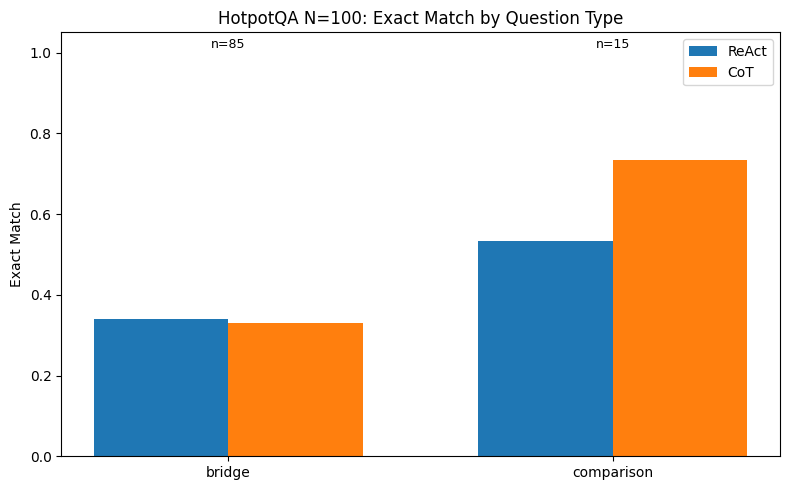

In [ ]:
# Plot EM by HotpotQA type

x = np.arange(len(type_summary))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, type_summary["react_em"], width, label="ReAct")
plt.bar(x + width/2, type_summary["cot_em"], width, label="CoT")

plt.ylabel("Exact Match")
plt.title("HotpotQA N=100: Exact Match by Question Type")
plt.xticks(x, type_summary["type"])
plt.ylim(0, 1.05)
plt.legend()

for i, row in type_summary.iterrows():
    plt.text(i, 1.01, f"n={row['n']}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("hotpotqa_n100_em_by_type.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ============================================================
# Statistical significance by HotpotQA question type
# Bridge vs Comparison
# ============================================================

import pandas as pd
import numpy as np
from scipy import stats

def significance_by_type(df, question_type):
    sub = df[df["type"] == question_type].copy()

    print("\n" + "="*90)
    print(f"Question type: {question_type.upper()} | n = {len(sub)}")
    print("="*90)

    if len(sub) == 0:
        print("No examples for this type.")
        return None

    # -------------------------
    # Basic means
    # -------------------------
    react_em = sub["react_em"].mean()
    cot_em = sub["cot_em"].mean()
    react_f1 = sub["react_f1"].mean()
    cot_f1 = sub["cot_f1"].mean()
    react_steps = sub["react_steps"].mean()
    cot_steps = sub["cot_steps"].mean()
    react_time = sub["react_time"].mean()
    cot_time = sub["cot_time"].mean()

    print(f"ReAct EM:   {react_em:.4f}")
    print(f"CoT EM:     {cot_em:.4f}")
    print(f"EM diff:    {react_em - cot_em:.4f}")

    print(f"\nReAct F1:   {react_f1:.4f}")
    print(f"CoT F1:     {cot_f1:.4f}")
    print(f"F1 diff:    {react_f1 - cot_f1:.4f}")

    print(f"\nReAct steps: {react_steps:.4f}")
    print(f"CoT steps:   {cot_steps:.4f}")
    print(f"Steps diff:  {react_steps - cot_steps:.4f}")

    print(f"\nReAct time: {react_time:.4f}")
    print(f"CoT time:   {cot_time:.4f}")
    print(f"Time diff:  {react_time - cot_time:.4f}")

    # -------------------------
    # McNemar test for EM
    # -------------------------
    b = int(((sub["react_em"] == 1) & (sub["cot_em"] == 0)).sum())
    c = int(((sub["react_em"] == 0) & (sub["cot_em"] == 1)).sum())

    if b + c > 0:
        mcnemar_p = stats.binomtest(
            k=min(b, c),
            n=b + c,
            p=0.5,
            alternative="two-sided"
        ).pvalue
    else:
        mcnemar_p = 1.0

    print("\nMcNemar Exact Match test:")
    print(f"ReAct correct / CoT wrong: {b}")
    print(f"ReAct wrong / CoT correct: {c}")
    print(f"p-value: {mcnemar_p:.4f}")
    print(f"Significant p<0.05: {mcnemar_p < 0.05}")

    # -------------------------
    # Wilcoxon tests for F1, steps, time
    # -------------------------
    def safe_wilcoxon(a, b, label):
        diff = a - b

        if (diff != 0).sum() == 0:
            print(f"\n{label}: all paired differences are zero; test not applicable.")
            return np.nan

        test = stats.wilcoxon(
            a,
            b,
            zero_method="wilcox",
            alternative="two-sided"
        )

        print(f"\nWilcoxon {label}:")
        print(f"statistic: {test.statistic:.4f}")
        print(f"p-value:   {test.pvalue:.4f}")
        print(f"Significant p<0.05: {test.pvalue < 0.05}")

        return test.pvalue

    f1_p = safe_wilcoxon(sub["react_f1"], sub["cot_f1"], "Token F1")
    steps_p = safe_wilcoxon(sub["react_steps"], sub["cot_steps"], "Steps")
    time_p = safe_wilcoxon(sub["react_time"], sub["cot_time"], "Time")

    return {
        "type": question_type,
        "n": len(sub),
        "react_em": react_em,
        "cot_em": cot_em,
        "em_diff": react_em - cot_em,
        "mcnemar_p": mcnemar_p,
        "react_f1": react_f1,
        "cot_f1": cot_f1,
        "f1_diff": react_f1 - cot_f1,
        "wilcoxon_f1_p": f1_p,
        "react_steps": react_steps,
        "cot_steps": cot_steps,
        "steps_diff": react_steps - cot_steps,
        "wilcoxon_steps_p": steps_p,
        "react_time": react_time,
        "cot_time": cot_time,
        "time_diff": react_time - cot_time,
        "wilcoxon_time_p": time_p,
    }


results_by_type = []

for qtype in ["bridge", "comparison"]:
    result = significance_by_type(hotpot_eval_df_100, qtype)
    if result is not None:
        results_by_type.append(result)

type_sig_df = pd.DataFrame(results_by_type)
type_sig_df


Question type: BRIDGE | n = 85
ReAct EM:   0.3412
CoT EM:     0.3294
EM diff:    0.0118

ReAct F1:   0.4475
CoT F1:     0.4360
F1 diff:    0.0115

ReAct steps: 4.4824
CoT steps:   1.0941
Steps diff:  3.3882

ReAct time: 9.0651
CoT time:   2.2872
Time diff:  6.7779

McNemar Exact Match test:
ReAct correct / CoT wrong: 8
ReAct wrong / CoT correct: 7
p-value: 1.0000
Significant p<0.05: False

Wilcoxon Token F1:
statistic: 190.0000
p-value:   0.7655
Significant p<0.05: False

Wilcoxon Steps:
statistic: 0.0000
p-value:   0.0000
Significant p<0.05: True

Wilcoxon Time:
statistic: 0.0000
p-value:   0.0000
Significant p<0.05: True

Question type: COMPARISON | n = 15
ReAct EM:   0.5333
CoT EM:     0.7333
EM diff:    -0.2000

ReAct F1:   0.5933
CoT F1:     0.7756
F1 diff:    -0.1822

ReAct steps: 4.2000
CoT steps:   2.0000
Steps diff:  2.2000

ReAct time: 6.9693
CoT time:   3.0347
Time diff:  3.9347

McNemar Exact Match test:
ReAct correct / CoT wrong: 0
ReAct wrong / CoT correct: 3
p-value: 0.

,type,n,react_em,cot_em,em_diff,mcnemar_p,react_f1,cot_f1,f1_diff,wilcoxon_f1_p,react_steps,cot_steps,steps_diff,wilcoxon_steps_p,react_time,cot_time,time_diff,wilcoxon_time_p
0,bridge,85,0.341176,0.329412,0.011765,1.00,0.447488,0.436037,0.011451,0.765482,4.482353,1.094118,3.388235,1.215670e-15,9.065059,2.287176,6.777882,1.168730e-15
1,comparison,15,0.533333,0.733333,-0.200000,0.25,0.593333,0.775556,-0.182222,0.042168,4.200000,2.000000,2.200000,1.755233e-02,6.969333,3.034667,3.934667,2.624512e-03


# Academic Quote Retrival Benchmarking

In [ ]:

import os
import re
import json
import math
import time
import requests
from typing import Dict, Any, List, Optional
from bs4 import BeautifulSoup
from urllib.parse import urlparse
import pandas as pd

In [ ]:
# ============================================================
# 1. Evidence benchmark: one expected claim per sentence
# ============================================================

EVIDENCE_BENCHMARK = [
    {
        "id": "e01_xgboost_soc",
        "paragraph": """
        XGBoost is a tree-based ensemble method that iteratively fits decision trees
        to minimize a specified loss function while controlling model complexity
        through regularization. The model is well suited for soil organic carbon
        prediction due to its ability to capture nonlinear relationships, feature
        interactions, and heterogeneous environmental responses across spatial and
        depth gradients.
        """,
        "expected_claims": [
            "XGBoost is a tree-based ensemble method that iteratively fits decision trees to minimize a regularized objective or loss function.",
            "XGBoost is well suited for soil organic carbon prediction because it can capture nonlinear relationships, feature interactions, and heterogeneous environmental responses."
        ],
        "gold_keywords": [
            "xgboost", "tree", "regularization",
            "nonlinear", "soil organic carbon"
        ],
    },
    {
        "id": "e02_rag_hallucination",
        "paragraph": """
        Retrieval augmented generation can reduce hallucinations by grounding
        language model outputs in external documents. Instead of relying only on
        parametric knowledge, the model retrieves relevant evidence and conditions
        its answer on that evidence.
        """,
        "expected_claims": [
            "Retrieval augmented generation can reduce hallucinations by grounding language model outputs in external documents.",
            "Instead of relying only on parametric knowledge, the model retrieves relevant evidence and conditions its answer on that evidence."
        ],
        "gold_keywords": [
            "retrieval", "external", "documents",
            "grounding", "hallucinations", "evidence"
        ],
    },
    {
        "id": "e03_lora_efficiency",
        "paragraph": """
        LoRA improves fine-tuning efficiency by freezing the original model weights
        and training low-rank adapter matrices. This greatly reduces the number of
        trainable parameters while preserving strong downstream performance.
        """,
        "expected_claims": [
            "LoRA improves fine-tuning efficiency by freezing the original model weights and training low-rank adapter matrices.",
            "LoRA reduces the number of trainable parameters while preserving strong downstream performance."
        ],
        "gold_keywords": [
            "lora", "low-rank", "frozen",
            "trainable parameters", "fine-tuning"
        ],
    },
    {
        "id": "e04_react_agents",
        "paragraph": """
        ReAct agents interleave reasoning traces with tool actions, allowing the
        model to update its plan after observing external information. This makes
        ReAct useful for tasks that require multi-step search or interaction with
        an environment.
        """,
        "expected_claims": [
            "ReAct agents interleave reasoning traces with tool actions, allowing the model to update its plan after observing external information.",
            "ReAct is useful for tasks that require multi-step search or interaction with an environment."
        ],
        "gold_keywords": [
            "react", "reasoning", "actions",
            "observing", "multi-step", "environment"
        ],
    },
    {
        "id": "e05_transformer_parallelization",
        "paragraph": """
        The Transformer architecture replaced recurrence with self-attention,
        making sequence modeling more parallelizable. Self-attention also shortens
        the path length between tokens, helping the model capture long-range
        dependencies.
        """,
        "expected_claims": [
            "The Transformer architecture replaced recurrence with self-attention, making sequence modeling more parallelizable.",
            "Self-attention shortens the path length between tokens, helping the model capture long-range dependencies."
        ],
        "gold_keywords": [
            "transformer", "self-attention", "recurrence",
            "parallel", "path length", "dependencies"
        ],
    },
    {
        "id": "e06_hnsw_vector_search",
        "paragraph": """
        HNSW is an approximate nearest neighbor search algorithm that organizes
        vectors in a hierarchical graph structure. It is widely used in vector
        databases because it provides low-latency similarity search over large
        embedding collections.
        """,
        "expected_claims": [
            "HNSW is an approximate nearest neighbor search algorithm that organizes vectors in a hierarchical graph structure.",
            "HNSW is widely used in vector databases because it provides low-latency similarity search over large embedding collections."
        ],
        "gold_keywords": [
            "hnsw", "approximate nearest neighbor", "hierarchical",
            "graph", "similarity search", "vector"
        ],
    },
    {
        "id": "e07_chinchilla_scaling",
        "paragraph": """
        The Chinchilla scaling law showed that many large language models were
        undertrained relative to their parameter count. For a fixed compute budget,
        better performance can often be achieved by training smaller models on more
        tokens rather than simply increasing model size.
        """,
        "expected_claims": [
            "The Chinchilla scaling law showed that many large language models were undertrained relative to their parameter count.",
            "For a fixed compute budget, better performance can often be achieved by training smaller models on more tokens rather than simply increasing model size."
        ],
        "gold_keywords": [
            "chinchilla", "compute", "undertrained",
            "tokens", "parameters", "smaller models"
        ],
    },
    {
        "id": "e08_toolformer",
        "paragraph": """
        Toolformer demonstrated that language models can learn to call external
        tools using self-supervised data generation. The model decides when to call
        a tool, what arguments to pass, and how to incorporate the tool result into
        later prediction.
        """,
        "expected_claims": [
            "Toolformer demonstrated that language models can learn to call external tools using self-supervised data generation.",
            "Toolformer decides when to call a tool, what arguments to pass, and how to incorporate the tool result into later prediction."
        ],
        "gold_keywords": [
            "toolformer", "tools", "self-supervised",
            "api", "arguments", "prediction"
        ],
    },
    {
        "id": "e09_bert_gpt_architectures",
        "paragraph": """
        BERT and GPT are both Transformer-based models, but they use different
        attention patterns and pretraining objectives. BERT is an encoder-only
        model trained with masked language modeling, while GPT is a decoder-only
        autoregressive model trained to predict the next token.
        """,
        "expected_claims": [
            "BERT and GPT are both Transformer-based models, but they use different attention patterns and pretraining objectives.",
            "BERT is an encoder-only model trained with masked language modeling, while GPT is a decoder-only autoregressive model trained to predict the next token."
        ],
        "gold_keywords": [
            "bert", "gpt", "transformer", "encoder",
            "decoder", "masked language modeling", "autoregressive"
        ],
    },
    {
        "id": "e10_synthetic_data_llm_eval",
        "paragraph": """
        Synthetic evaluation datasets can help test language models on controlled
        tasks where the correct answer is automatically known. However, synthetic
        benchmarks may fail to capture the ambiguity and distributional complexity
        of real-world user queries.
        """,
        "expected_claims": [
            "Synthetic evaluation datasets can help test language models on controlled tasks where the correct answer is automatically known.",
            "Synthetic benchmarks may fail to capture the ambiguity and distributional complexity of real-world user queries."
        ],
        "gold_keywords": [
            "synthetic", "evaluation", "benchmark",
            "controlled", "real-world", "distribution"
        ],
    },
]

In [ ]:
# ============================================================
# 2. Stronger parser for find_paper_quotes and baseline outputs
# ============================================================


NO_QUOTE_PATTERNS = [
    "no exact quote available",
    "no quote available",
    "exact quote not available",
    "not available from snippet",
    "no exact quote available from snippet",
    "no direct quote available",
    "no verbatim quote available",
    "quote unavailable",
]

TRUNCATION_PATTERNS = [
    "...",
    "[...]",
    "…",
]


def is_real_quote_text(q: str) -> bool:
    """
    Determines whether a parsed quote is actually usable evidence.
    This prevents baseline placeholders from being counted as quotes.
    """

    q_clean = str(q).strip()
    q_lower = q_clean.lower()

    if not q_clean:
        return False

    if any(p in q_lower for p in NO_QUOTE_PATTERNS):
        return False

    # Too short to be meaningful evidence.
    if len(q_clean.split()) < 6:
        return False

    return True


def is_truncated_quote(q: str) -> bool:
    """
    Detects quote snippets that are probably incomplete.
    This does not make them fake, but they should receive lower credit.
    """

    q_clean = str(q).strip()

    if any(p in q_clean for p in TRUNCATION_PATTERNS):
        return True

    # Ends without normal sentence punctuation often means snippet fragment.
    if not re.search(r'[.!?]"?$', q_clean):
        return True

    return False


def normalize_url(url: str) -> str:
    return str(url).strip().rstrip(".,);]")


def source_domain(url: str) -> str:
    try:
        return urlparse(url).netloc.lower().replace("www.", "")
    except Exception:
        return ""


def source_quality_tier(url: str) -> float:
    """
    Scores source quality based on domain class.
    This is intentionally simple and transparent.
    """

    domain = source_domain(url)

    elite = [
        "arxiv.org",
        "nature.com",
        "science.org",
        "cell.com",
        "pnas.org",
        "jmlr.org",
        "acm.org",
        "dl.acm.org",
        "ieee.org",
        "ieeexplore.ieee.org",
        "neurips.cc",
        "proceedings.mlr.press",
        "kdd.org",
        "openreview.net",
    ]

    strong_scholarly = [
        "pmc.ncbi.nlm.nih.gov",
        "pubmed.ncbi.nlm.nih.gov",
        "frontiersin.org",
        "springer.com",
        "link.springer.com",
        "sciencedirect.com",
        "wiley.com",
        "mdpi.com",
        "plos.org",
        "tandfonline.com",
    ]

    institutional_or_docs = [
        ".edu",
        ".gov",
        "readthedocs.io",
        "anthropic.com",
        "openai.com",
        "huggingface.co",
        "apache.org",
    ]

    weak = [
        "medium.com",
        "towardsdatascience.com",
        "linkedin.com",
        "substack.com",
        "blogspot.com",
        "wordpress.com",
        "geeksforgeeks.org",
        "analyticsvidhya.com",
        "stackoverflow.blog",
        "salesforce.com",
    ]

    if any(d in domain for d in elite):
        return 1.0

    if any(d in domain for d in strong_scholarly):
        return 0.85

    if any(d in domain for d in institutional_or_docs) or domain.endswith(".edu") or domain.endswith(".gov"):
        return 0.65

    if any(d in domain for d in weak):
        return 0.25

    return 0.45


def parse_quote_tool_output(output: str) -> Dict[str, Any]:
    """
    Stronger parser.

    Extracts:
    - URLs
    - real quotes only
    - truncated quote count
    - verified quote count
    - claim/source lines
    - source quality score
    """

    if output is None:
        output = ""

    text = str(output)

    urls = [
        normalize_url(u)
        for u in re.findall(r"https?://[^\s\]\)\},]+", text)
    ]
    urls = list(dict.fromkeys(urls))

    # Exact quoted spans.
    quoted_spans = []
    quoted_spans += re.findall(r'"([^"]{20,3000})"', text)
    quoted_spans += re.findall(r'“([^”]{20,3000})”', text)

    # Quote: lines.
    quote_lines = []

    for line in text.splitlines():
        clean = line.strip()

        if re.search(r"\bquote\s*:", clean, re.IGNORECASE):
            quote_candidate = re.sub(
                r"^.*?\bquote\s*:\s*",
                "",
                clean,
                flags=re.IGNORECASE,
            ).strip()
            quote_candidate = quote_candidate.strip('"“”`')
            quote_lines.append(quote_candidate)

        if clean.startswith(">") and len(clean) >= 30:
            quote_lines.append(clean.lstrip(">").strip())

    raw_quotes = list(dict.fromkeys(quoted_spans + quote_lines))
    real_quotes = [q for q in raw_quotes if is_real_quote_text(q)]

    truncated_quotes = [q for q in real_quotes if is_truncated_quote(q)]

    # find_paper_quotes explicitly prints Verified: True.
    verified_count = len(re.findall(r"Verified:\s*True", text, flags=re.IGNORECASE))

    claims = []
    for line in text.splitlines():
        clean = line.strip()
        if re.search(r"^Claim\b|\bClaim C\d+\b|\bcitation claim\b|\bclaim id\b", clean, re.IGNORECASE):
            if len(clean) > 10:
                claims.append(clean)

    sources = []
    for line in text.splitlines():
        clean = line.strip()
        if re.search(r"\bsource title\b|\bsource:\b|\bpaper\b|\bcitation\b|\bauthor\b", clean, re.IGNORECASE):
            if len(clean) > 10 and not clean.lower().startswith("http"):
                sources.append(clean)

    source_quality_scores = [source_quality_tier(u) for u in urls]
    mean_source_quality = (
        sum(source_quality_scores) / len(source_quality_scores)
        if source_quality_scores else 0.0
    )

    # Number of non-placeholder Quote: fields.
    real_quote_line_count = sum(
        1 for q in quote_lines
        if is_real_quote_text(q)
    )

    return {
        "raw_output": text,
        "urls": urls,
        "quotes": real_quotes,
        "raw_quotes": raw_quotes,
        "truncated_quotes": truncated_quotes,
        "claims": claims,
        "sources": sources,
        "num_urls": len(urls),
        "num_quotes": len(real_quotes),
        "num_raw_quote_fields": len(raw_quotes),
        "num_real_quote_lines": real_quote_line_count,
        "num_truncated_quotes": len(truncated_quotes),
        "num_verified_quotes": verified_count,
        "num_claim_like_lines": len(claims),
        "num_source_like_lines": len(sources),
        "mean_source_quality": mean_source_quality,
        "source_quality_scores": source_quality_scores,
    }

In [ ]:
# ============================================================
# 3. Stronger metrics
# ============================================================

def keyword_coverage(text: str, keywords: List[str]) -> float:
    text_lower = str(text).lower()
    hits = sum(1 for k in keywords if k.lower() in text_lower)
    return hits / len(keywords) if keywords else 1.0


def expected_claim_coverage(output: str, expected_claims: List[str]) -> float:
    """
    Proxy for whether expected claim concepts appear in output.
    Still imperfect, but okay as a lightweight automatic metric.
    """

    output_lower = str(output).lower()

    covered = 0
    for claim in expected_claims:
        words = [
            w.lower()
            for w in re.findall(r"[a-zA-Z][a-zA-Z\-]+", claim)
            if len(w) > 4
        ]

        if not words:
            continue

        hits = sum(1 for w in words if w in output_lower)

        if hits / len(words) >= 0.35:
            covered += 1

    return covered / len(expected_claims) if expected_claims else 1.0


def source_found(parsed: Dict[str, Any]) -> int:
    return int(parsed["num_urls"] > 0 or parsed["num_source_like_lines"] > 0)


def quote_found(parsed: Dict[str, Any]) -> int:
    """
    A quote is found only if it is a real quote,
    not a placeholder like 'No exact quote available from snippet.'
    """
    return int(parsed["num_quotes"] > 0)


def verified_quote_found(parsed: Dict[str, Any]) -> int:
    return int(parsed["num_verified_quotes"] > 0)


def quote_density(parsed: Dict[str, Any], expected_num_claims: int) -> float:
    """
    Real quotes per expected claim, capped at 1.
    """
    if expected_num_claims == 0:
        return 1.0
    return min(parsed["num_quotes"] / expected_num_claims, 1.0)


def verified_quote_density(parsed: Dict[str, Any], expected_num_claims: int) -> float:
    """
    Verified quotes per expected claim, capped at 1.
    Baseline will usually get 0 because it does not verify quotes.
    """
    if expected_num_claims == 0:
        return 1.0
    return min(parsed["num_verified_quotes"] / expected_num_claims, 1.0)


def complete_claim_quote_coverage(parsed: Dict[str, Any], expected_num_claims: int) -> int:
    """
    Did the system return at least one real quote per expected claim?
    """
    if expected_num_claims == 0:
        return 1
    return int(parsed["num_quotes"] >= expected_num_claims)


def complete_verified_claim_quote_coverage(parsed: Dict[str, Any], expected_num_claims: int) -> int:
    """
    Did the system return at least one verified quote per expected claim?
    """
    if expected_num_claims == 0:
        return 1
    return int(parsed["num_verified_quotes"] >= expected_num_claims)


def quote_completeness_score(parsed: Dict[str, Any]) -> float:
    """
    Penalizes truncated quote snippets.
    """
    if parsed["num_quotes"] == 0:
        return 0.0

    complete_quotes = parsed["num_quotes"] - parsed["num_truncated_quotes"]
    return max(0.0, complete_quotes / parsed["num_quotes"])


def citation_readiness_score(parsed: Dict[str, Any], expected_num_claims: int) -> float:
    """
    Better citation-readiness score.

    Rewards:
    - real quotes
    - quote coverage across claims
    - verified quotes
    - URLs/source metadata
    - scholarly source quality

    Penalizes:
    - no real quotes
    - truncated snippet quotes
    - weak source quality
    """

    score = 0.0

    # Source exists.
    if source_found(parsed):
        score += 0.15

    # Real quote exists.
    if parsed["num_quotes"] > 0:
        score += 0.20

    # Enough quotes for expected claims.
    score += 0.20 * quote_density(parsed, expected_num_claims)

    # Verified quotes matter a lot.
    score += 0.20 * verified_quote_density(parsed, expected_num_claims)

    # Source quality matters.
    score += 0.15 * parsed["mean_source_quality"]

    # Complete/non-truncated quotes.
    score += 0.10 * quote_completeness_score(parsed)

    return round(min(score, 1.0), 3)

In [ ]:
# ============================================================
# 4. Generic weaker baseline
# ============================================================

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage

def generic_web_quote_baseline(paragraph: str) -> str:
    """
    Weaker baseline:
    - Runs one generic web_search query on the paragraph.
    - Asks the LLM to suggest sources and quotes using only search snippets.
    - Does not do claim decomposition, PDF extraction, quote verification, or reranking.
    """

    search_result = web_search.invoke(paragraph[:700])

    llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

    response = llm.invoke([
        SystemMessage(content="""
        You are a weak baseline research assistant.

        Given a paragraph and web search results, suggest sources and supporting quotes.
        Use only the provided search results.
        Do not open links.
        Do not extract PDFs.
        Do not verify quotes.
        Do not invent exact quotes.
        If exact quotes are not available in the search results, say exactly:
        "No exact quote available from snippet."

        Output format:
        Claim:
        Source:
        URL:
        Quote:
        """),
        HumanMessage(content=f"""
        Paragraph:
        {paragraph}

        Web search results:
        {search_result}
        """)
    ])

    return response.content

In [ ]:
# ============================================================
# 5. Evaluation runner
# ============================================================

def evaluate_evidence_system(
    benchmark: List[Dict[str, Any]],
    system_name: str,
    tool_fn,
    verbose: bool = True,
) -> pd.DataFrame:
    """
    Runs an evidence retrieval system on the benchmark.

    tool_fn:
      Function that takes paragraph string and returns raw output string.

    Returns:
      DataFrame with one row per benchmark item.
    """

    rows = []

    for item in benchmark:
        qid = item["id"]
        paragraph = item["paragraph"].strip()
        expected_claims = item["expected_claims"]
        gold_keywords = item["gold_keywords"]
        n_claims = len(expected_claims)

        if verbose:
            print("=" * 90)
            print(f"[{system_name}] Running {qid}")
            print("=" * 90)

        start = time.perf_counter()

        try:
            output = tool_fn(paragraph)
            error = ""
        except Exception as e:
            output = ""
            error = str(e)

        end = time.perf_counter()
        latency_sec = end - start

        parsed = parse_quote_tool_output(output)

        row = {
            "system": system_name,
            "id": qid,
            "latency_sec": round(latency_sec, 3),
            "error": error,

            # Benchmark structure
            "num_expected_claims": n_claims,

            # Parsed evidence counts
            "num_urls": parsed["num_urls"],
            "num_quotes": parsed["num_quotes"],
            "num_raw_quote_fields": parsed["num_raw_quote_fields"],
            "num_truncated_quotes": parsed["num_truncated_quotes"],
            "num_verified_quotes": parsed["num_verified_quotes"],
            "num_claim_like_lines": parsed["num_claim_like_lines"],
            "num_source_like_lines": parsed["num_source_like_lines"],

            # Binary indicators
            "source_found": source_found(parsed),
            "quote_found": quote_found(parsed),
            "verified_quote_found": verified_quote_found(parsed),
            "complete_claim_quote_coverage": complete_claim_quote_coverage(parsed, n_claims),
            "complete_verified_claim_quote_coverage": complete_verified_claim_quote_coverage(parsed, n_claims),

            # Evidence quality metrics
            "quote_density": quote_density(parsed, n_claims),
            "verified_quote_density": verified_quote_density(parsed, n_claims),
            "quote_completeness": quote_completeness_score(parsed),
            "mean_source_quality": parsed["mean_source_quality"],

            # Content proxy metrics
            "keyword_coverage": keyword_coverage(output, gold_keywords),
            "expected_claim_coverage": expected_claim_coverage(output, expected_claims),

            # Overall citation-readiness
            "citation_readiness": citation_readiness_score(parsed, n_claims),

            # Store raw output
            "raw_output": output,
        }

        rows.append(row)

        if verbose:
            print(f"Latency: {row['latency_sec']} sec")
            print(f"Expected claims: {row['num_expected_claims']}")
            print(f"URLs found: {row['num_urls']}")
            print(f"Raw quote fields: {row['num_raw_quote_fields']}")
            print(f"Real quotes found: {row['num_quotes']}")
            print(f"Verified quotes found: {row['num_verified_quotes']}")
            print(f"Source found: {row['source_found']}")
            print(f"Quote found: {row['quote_found']}")
            print(f"Verified quote found: {row['verified_quote_found']}")
            print(f"Quote density: {row['quote_density']:.2f}")
            print(f"Verified quote density: {row['verified_quote_density']:.2f}")
            print(f"Complete claim quote coverage: {row['complete_claim_quote_coverage']}")
            print(f"Complete verified claim quote coverage: {row['complete_verified_claim_quote_coverage']}")
            print(f"Mean source quality: {row['mean_source_quality']:.2f}")
            print(f"Keyword coverage: {row['keyword_coverage']:.2f}")
            print(f"Expected claim coverage: {row['expected_claim_coverage']:.2f}")
            print(f"Citation readiness: {row['citation_readiness']:.2f}")

            if error:
                print("ERROR:", error)

            print()

    return pd.DataFrame(rows)

In [ ]:
# ============================================================
# 6. Run both systems
# ============================================================

find_paper_quotes_eval_df = evaluate_evidence_system(
    benchmark=EVIDENCE_BENCHMARK,
    system_name="find_paper_quotes",
    tool_fn=lambda paragraph: find_paper_quotes.invoke(paragraph),
    verbose=True,
)

baseline_eval_df = evaluate_evidence_system(
    benchmark=EVIDENCE_BENCHMARK,
    system_name="generic_web_baseline",
    tool_fn=generic_web_quote_baseline,
    verbose=True,
)

all_eval_df = pd.concat(
    [find_paper_quotes_eval_df, baseline_eval_df],
    ignore_index=True
)

display_cols = [
    "system",
    "id",
    "latency_sec",
    "num_expected_claims",
    "num_urls",
    "num_quotes",
    "num_raw_quote_fields",
    "num_verified_quotes",
    "source_found",
    "quote_found",
    "verified_quote_found",
    "quote_density",
    "verified_quote_density",
    "complete_claim_quote_coverage",
    "complete_verified_claim_quote_coverage",
    "mean_source_quality",
    "keyword_coverage",
    "expected_claim_coverage",
    "citation_readiness",
    "error",
]

all_eval_df[display_cols]

[find_paper_quotes] Running e01_xgboost_soc
Latency: 27.733 sec
Expected claims: 2
URLs found: 2
Raw quote fields: 2
Real quotes found: 2
Verified quotes found: 2
Source found: 1
Quote found: 1
Verified quote found: 1
Quote density: 1.00
Verified quote density: 1.00
Complete claim quote coverage: 1
Complete verified claim quote coverage: 1
Mean source quality: 0.93
Keyword coverage: 1.00
Expected claim coverage: 1.00
Citation readiness: 0.99

[find_paper_quotes] Running e02_rag_hallucination
Latency: 17.729 sec
Expected claims: 2
URLs found: 2
Raw quote fields: 2
Real quotes found: 2
Verified quotes found: 2
Source found: 1
Quote found: 1
Verified quote found: 1
Quote density: 1.00
Verified quote density: 1.00
Complete claim quote coverage: 1
Complete verified claim quote coverage: 1
Mean source quality: 1.00
Keyword coverage: 1.00
Expected claim coverage: 1.00
Citation readiness: 1.00

[find_paper_quotes] Running e03_lora_efficiency
Latency: 19.151 sec
Expected claims: 2
URLs found: 2

,system,id,latency_sec,num_expected_claims,num_urls,num_quotes,num_raw_quote_fields,num_verified_quotes,source_found,quote_found,verified_quote_found,quote_density,verified_quote_density,complete_claim_quote_coverage,complete_verified_claim_quote_coverage,mean_source_quality,keyword_coverage,expected_claim_coverage,citation_readiness,error
0,find_paper_quotes,e01_xgboost_soc,27.733,2,2,2,2,2,1,1,1,1.0,1.0,1,1,0.925000,1.000000,1.0,0.989,
1,find_paper_quotes,e02_rag_hallucination,17.729,2,2,2,2,2,1,1,1,1.0,1.0,1,1,1.000000,1.000000,1.0,1.000,
2,find_paper_quotes,e03_lora_efficiency,19.151,2,2,2,2,2,1,1,1,1.0,1.0,1,1,1.000000,0.800000,1.0,1.000,
3,find_paper_quotes,e04_react_agents,17.589,2,2,2,2,2,1,1,1,1.0,1.0,1,1,1.000000,1.000000,1.0,1.000,
4,find_paper_quotes,e05_transformer_parallelization,18.365,2,2,2,2,2,1,1,1,1.0,1.0,1,1,1.000000,1.000000,1.0,1.000,
5,find_paper_quotes,e06_hnsw_vector_search,15.159,2,2,2,2,2,1,1,1,1.0,1.0,1,1,1.000000,1.000000,1.0,1.000,
6,find_paper_quotes,e07_chinchilla_scaling,19.122,2,2,2,2,2,1,1,1,1.0,1.0,1,1,0.725000,1.000000,1.0,0.959,
7,find_paper_quotes,e08_toolformer,14.579,2,1,2,2,2,1,1,1,1.0,1.0,1,1,1.000000,1.000000,1.0,1.000,
8,find_paper_quotes,e09_bert_gpt_architectures,12.713,2,4,2,2,2,1,1,1,1.0,1.0,1,1,0.775000,1.000000,1.0,0.966,
9,find_paper_quotes,e10_synthetic_data_llm_eval,12.826,2,2,2,2,2,1,1,1,1.0,1.0,1,1,1.000000,1.000000,1.0,1.000,


In [ ]:
# ============================================================
# 7. Summary comparison table
# ============================================================

summary_df = (
    all_eval_df
    .groupby("system")
    .agg(
        mean_latency_sec=("latency_sec", "mean"),
        median_latency_sec=("latency_sec", "median"),
        total_runtime_sec=("latency_sec", "sum"),

        source_found_rate=("source_found", "mean"),
        quote_found_rate=("quote_found", "mean"),
        verified_quote_found_rate=("verified_quote_found", "mean"),

        complete_claim_quote_coverage_rate=("complete_claim_quote_coverage", "mean"),
        complete_verified_claim_quote_coverage_rate=("complete_verified_claim_quote_coverage", "mean"),

        mean_quote_density=("quote_density", "mean"),
        mean_verified_quote_density=("verified_quote_density", "mean"),
        mean_quote_completeness=("quote_completeness", "mean"),
        mean_source_quality=("mean_source_quality", "mean"),

        mean_keyword_coverage=("keyword_coverage", "mean"),
        mean_expected_claim_coverage=("expected_claim_coverage", "mean"),
        mean_citation_readiness=("citation_readiness", "mean"),

        mean_num_urls=("num_urls", "mean"),
        mean_num_quotes=("num_quotes", "mean"),
        mean_num_verified_quotes=("num_verified_quotes", "mean"),

        failure_rate=("error", lambda x: (x.astype(str).str.len() > 0).mean()),
    )
    .reset_index()
)

summary_df = summary_df.round(3)

print(summary_df.to_markdown(index=False))

| system               |   mean_latency_sec |   median_latency_sec |   total_runtime_sec |   source_found_rate |   quote_found_rate |   verified_quote_found_rate |   complete_claim_quote_coverage_rate |   complete_verified_claim_quote_coverage_rate |   mean_quote_density |   mean_verified_quote_density |   mean_quote_completeness |   mean_source_quality |   mean_keyword_coverage |   mean_expected_claim_coverage |   mean_citation_readiness |   mean_num_urls |   mean_num_quotes |   mean_num_verified_quotes |   failure_rate |
|:---------------------|-------------------:|---------------------:|--------------------:|--------------------:|-------------------:|----------------------------:|-------------------------------------:|----------------------------------------------:|---------------------:|------------------------------:|--------------------------:|----------------------:|------------------------:|-------------------------------:|--------------------------:|----------------:|---------

In [ ]:
# ============================================================
# 8. Per-example comparison table
# ============================================================

compact_cols = [
    "system",
    "id",
    "latency_sec",
    "num_expected_claims",
    "num_urls",
    "num_quotes",
    "num_verified_quotes",
    "quote_density",
    "verified_quote_density",
    "complete_claim_quote_coverage",
    "complete_verified_claim_quote_coverage",
    "mean_source_quality",
    "keyword_coverage",
    "expected_claim_coverage",
    "citation_readiness",
]

compact_df = all_eval_df[compact_cols].copy()
compact_df = compact_df.round(3)

print(compact_df.to_markdown(index=False))

| system               | id                              |   latency_sec |   num_expected_claims |   num_urls |   num_quotes |   num_verified_quotes |   quote_density |   verified_quote_density |   complete_claim_quote_coverage |   complete_verified_claim_quote_coverage |   mean_source_quality |   keyword_coverage |   expected_claim_coverage |   citation_readiness |
|:---------------------|:--------------------------------|--------------:|----------------------:|-----------:|-------------:|----------------------:|----------------:|-------------------------:|--------------------------------:|-----------------------------------------:|----------------------:|-------------------:|--------------------------:|---------------------:|
| find_paper_quotes    | e01_xgboost_soc                 |        27.733 |                     2 |          2 |            2 |                     2 |             1   |                        1 |                               1 |                                 

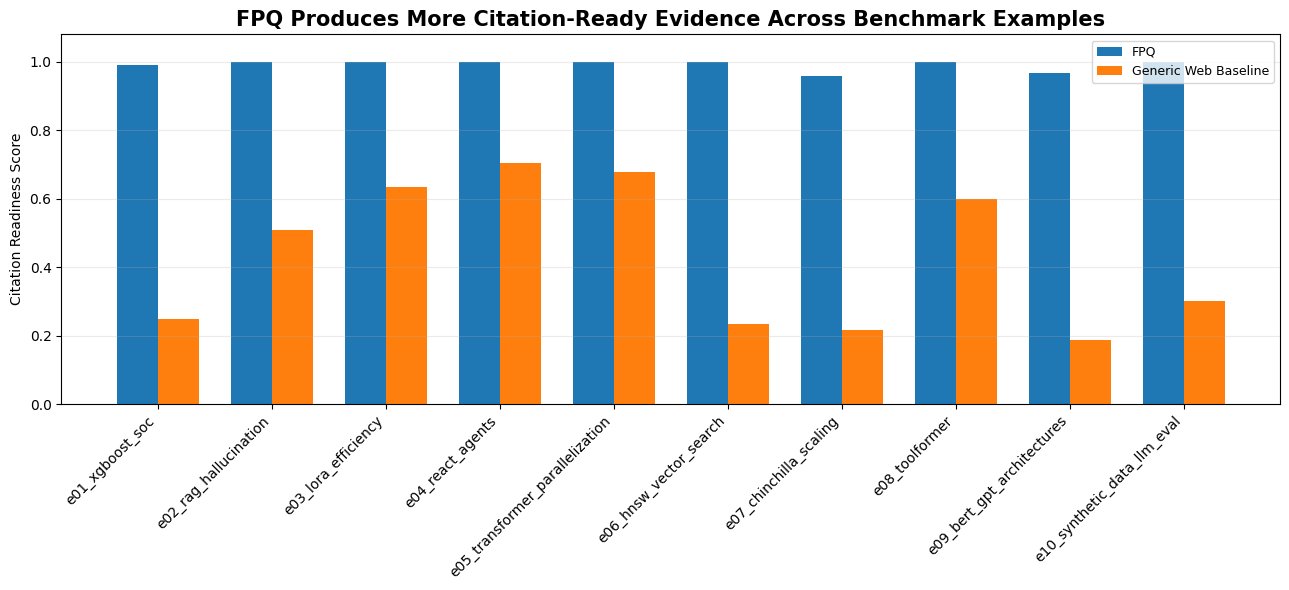

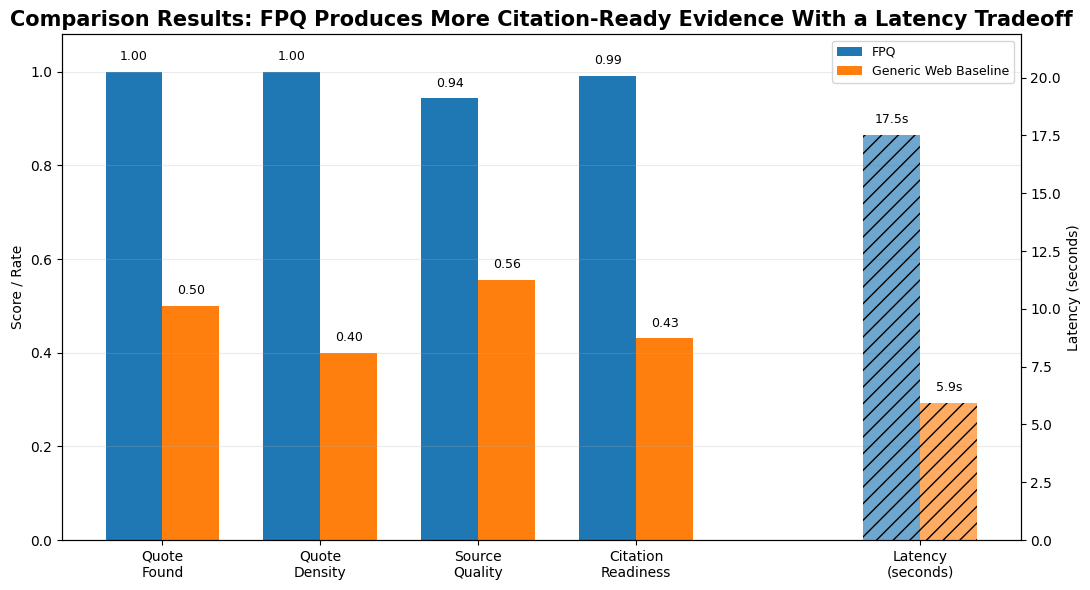

Saved final figures to: fpq_best_figures/


In [ ]:
# ============================================================
# FINAL FPQ BENCHMARK VISUALIZATIONS
# 1) Citation readiness across benchmark examples
# 2) Comparison Results: citation readiness + latency tradeoff
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

OUT_DIR = "fpq_best_figures"
os.makedirs(OUT_DIR, exist_ok=True)

plot_df = all_eval_df.copy()
plot_df["system_label"] = plot_df["system"].map({
    "find_paper_quotes": "FPQ",
    "generic_web_baseline": "Generic Web Baseline"
}).fillna(plot_df["system"])

summary_plot = summary_df.copy()
summary_plot["system_label"] = summary_plot["system"].map({
    "find_paper_quotes": "FPQ",
    "generic_web_baseline": "Generic Web Baseline"
}).fillna(summary_plot["system"])

COLORS = {
    "FPQ": "#1f77b4",
    "Generic Web Baseline": "#ff7f0e"
}

legend_handles = [
    Patch(facecolor=COLORS["FPQ"], label="FPQ"),
    Patch(facecolor=COLORS["Generic Web Baseline"], label="Generic Web Baseline")
]

system_order = ["FPQ", "Generic Web Baseline"]


# ============================================================
# GRAPH 1: Citation readiness by benchmark example
# ============================================================

pivot_ready = plot_df.pivot(
    index="id",
    columns="system_label",
    values="citation_readiness"
)

pivot_ready = pivot_ready[system_order]

x = np.arange(len(pivot_ready.index))
width = 0.36

fig, ax = plt.subplots(figsize=(13, 6))

ax.bar(
    x - width / 2,
    pivot_ready["FPQ"],
    width,
    color=COLORS["FPQ"]
)

ax.bar(
    x + width / 2,
    pivot_ready["Generic Web Baseline"],
    width,
    color=COLORS["Generic Web Baseline"]
)

ax.set_xticks(x)
ax.set_xticklabels(pivot_ready.index, rotation=45, ha="right")
ax.set_ylim(0, 1.08)
ax.set_ylabel("Citation Readiness Score")

ax.set_title(
    "FPQ Produces More Citation-Ready Evidence Across Benchmark Examples",
    fontsize=15,
    weight="bold"
)

ax.grid(axis="y", alpha=0.25)

ax.legend(
    handles=legend_handles,
    loc="upper right",
    frameon=True,
    fontsize=9
)

plt.tight_layout()
plt.savefig(
    f"{OUT_DIR}/01_citation_readiness_across_examples.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# ============================================================
# GRAPH 2: Comparison Results
# Citation readiness + source quality + quote density + latency
# Removes verified quote found, complete verified coverage,
# real quotes, and URLs
# ============================================================

score_metrics = [
    "quote_found_rate",
    "mean_quote_density",
    "mean_source_quality",
    "mean_citation_readiness",
]

score_labels = [
    "Quote\nFound",
    "Quote\nDensity",
    "Source\nQuality",
    "Citation\nReadiness",
]

latency_metric = "mean_latency_sec"

score_data = summary_plot.set_index("system_label").loc[
    system_order,
    score_metrics
].T

latency_data = summary_plot.set_index("system_label").loc[
    system_order,
    latency_metric
]

x_scores = np.arange(len(score_metrics))
latency_x = len(score_metrics) + 0.8
width = 0.36

fig, ax1 = plt.subplots(figsize=(11, 6))

# Score/rate bars
ax1.bar(
    x_scores - width / 2,
    score_data["FPQ"],
    width,
    color=COLORS["FPQ"]
)

ax1.bar(
    x_scores + width / 2,
    score_data["Generic Web Baseline"],
    width,
    color=COLORS["Generic Web Baseline"]
)

ax1.set_ylabel("Score / Rate")
ax1.set_ylim(0, 1.08)
ax1.grid(axis="y", alpha=0.25)

for i, metric in enumerate(score_metrics):
    fpq_val = score_data.loc[metric, "FPQ"]
    base_val = score_data.loc[metric, "Generic Web Baseline"]

    ax1.text(
        i - width / 2,
        fpq_val + 0.025,
        f"{fpq_val:.2f}",
        ha="center",
        fontsize=9
    )

    ax1.text(
        i + width / 2,
        base_val + 0.025,
        f"{base_val:.2f}",
        ha="center",
        fontsize=9
    )

# Latency bars on second axis
ax2 = ax1.twinx()

ax2.bar(
    latency_x - width / 2,
    latency_data["FPQ"],
    width,
    color=COLORS["FPQ"],
    alpha=0.65,
    hatch="//"
)

ax2.bar(
    latency_x + width / 2,
    latency_data["Generic Web Baseline"],
    width,
    color=COLORS["Generic Web Baseline"],
    alpha=0.65,
    hatch="//"
)

ax2.set_ylabel("Latency (seconds)")

latency_max = max(
    latency_data["FPQ"],
    latency_data["Generic Web Baseline"]
)

ax2.set_ylim(0, latency_max * 1.25 if latency_max > 0 else 1)

ax2.text(
    latency_x - width / 2,
    latency_data["FPQ"] + latency_max * 0.03,
    f"{latency_data['FPQ']:.1f}s",
    ha="center",
    fontsize=9
)

ax2.text(
    latency_x + width / 2,
    latency_data["Generic Web Baseline"] + latency_max * 0.03,
    f"{latency_data['Generic Web Baseline']:.1f}s",
    ha="center",
    fontsize=9
)

all_x = list(x_scores) + [latency_x]
all_labels = score_labels + ["Latency\n(seconds)"]

ax1.set_xticks(all_x)
ax1.set_xticklabels(all_labels)

ax1.set_title(
    "Comparison Results: FPQ Produces More Citation-Ready Evidence With a Latency Tradeoff",
    fontsize=15,
    weight="bold"
)

ax1.legend(
    handles=legend_handles,
    loc="upper right",
    frameon=True,
    fontsize=9
)

plt.tight_layout()
plt.savefig(
    f"{OUT_DIR}/02_comparison_results_latency_tradeoff.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


print(f"Saved final figures to: {OUT_DIR}/")